## Importovanje biblioteka

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

##  Ucitavanje podataka

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/job_descriptions.csv')

print(f"Oblik skupa: {df.shape}")
print(df.columns.tolist())
df.head()

Mounted at /content/drive
Oblik skupa: (1615940, 23)
['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile']


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


## Preprocesiranje
### Provera i uklanjanje nedostajucih vrednosti

In [ ]:
print("--- Provera nedostajucih vrednosti (NaN) ---")
print(df.isnull().sum())

df = df.dropna()
df.columns = [col.strip().lower() for col in df.columns]
print(f"\nNakon dropna: {df.shape}")

--- Provera nedostajucih vrednosti (NaN) ---
Job Id                 0
Experience             0
Qualifications         0
Salary Range           0
location               0
Country                0
latitude               0
longitude              0
Work Type              0
Company Size           0
Job Posting Date       0
Preference             0
Contact Person         0
Contact                0
Job Title              0
Role                   0
Job Portal             0
Job Description        0
Benefits               0
skills                 0
Responsibilities       0
Company                0
Company Profile     5478
dtype: int64

Nakon dropna: (1610462, 23)


### Analiza distribucije klasa

--- Analiza balansiranosti klasa (Top 20 poslova) ---


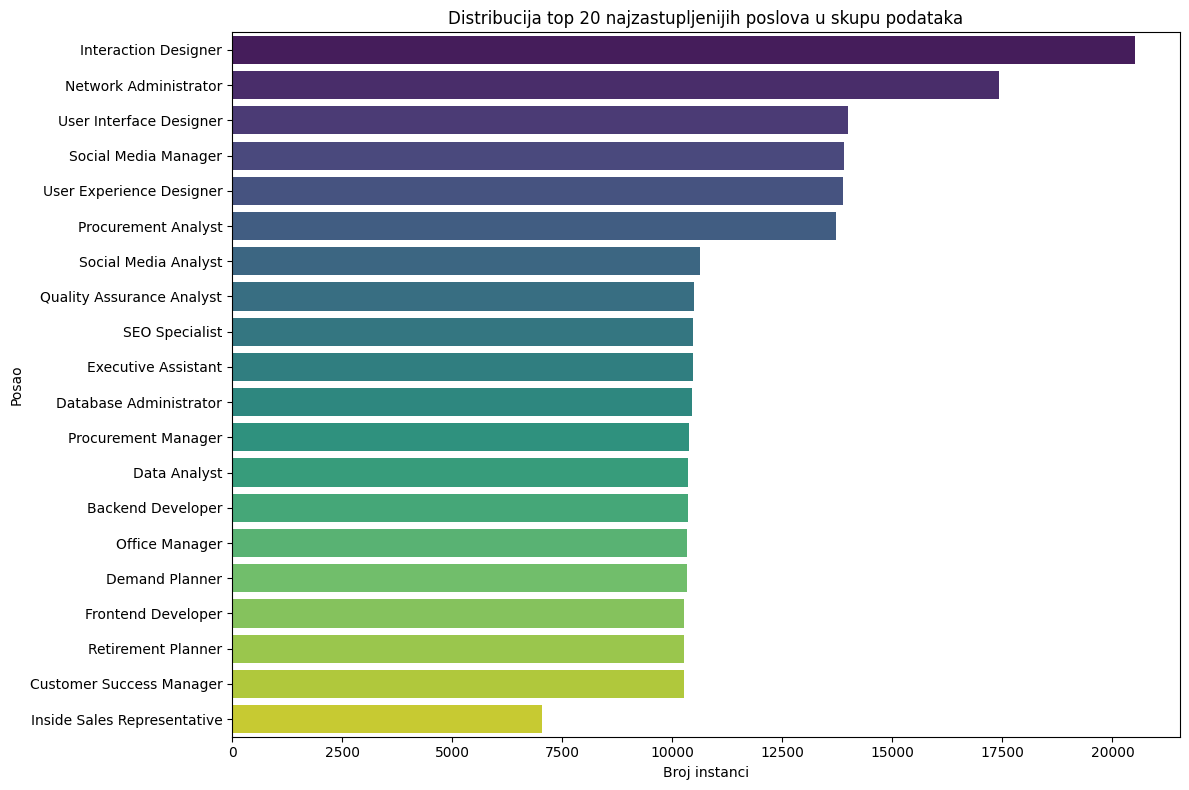


Procentualni udeo top 5 poslova:
role
Interaction Designer        1.273423
Network Administrator       1.081118
User Interface Designer     0.868260
Social Media Manager        0.862982
User Experience Designer    0.862175
Name: proportion, dtype: float64
Prosečan udeo po klasi: 0.266%


In [ ]:
print("--- Analiza balansiranosti klasa (Top 20 poslova) ---")
role_counts = df['role'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=role_counts.head(20).values, y=role_counts.head(20).index, palette='viridis')
plt.title('Distribucija top 20 najzastupljenijih poslova u skupu podataka')
plt.xlabel('Broj instanci')
plt.ylabel('Posao')
plt.tight_layout()
plt.show()

print("\nProcentualni udeo top 5 poslova:")
print(df['role'].value_counts(normalize=True).head(5) * 100)
print(f"Prosečan udeo po klasi: {100/df['role'].nunique():.3f}%")

### Stratifikovano uzorkovanje (5% po klasi zbog veličine skupa podataka)

In [ ]:
frac = 0.05
df_sample = df.groupby('role', group_keys=False).apply(lambda x: x.sample(frac=frac, random_state=42))
print(f"Novi broj redova: {len(df_sample)}")

Novi broj redova: 80521


In [ ]:
df.to_csv('/content/drive/MyDrive/IP2SkupoviPodataka/job_descriptions_original.csv', index=False)
print(f"Sacuvan originalni skup: {df.shape}")

### Label encoding ciljnih promenljivih

In [ ]:
le = LabelEncoder()
y = le.fit_transform(df_sample['role'])

le_work = LabelEncoder()
y_work = le_work.fit_transform(df_sample['work type'])

print("Klase role:", le.classes_[:5], "...")
print("Klase work type:", le_work.classes_)

Klase role: ['API Developer' 'Accessibility Developer' 'Account Executive'
 'Account Manager' 'Account Strategist'] ...
Klase work type: ['Contract' 'Full-Time' 'Intern' 'Part-Time' 'Temporary']


### Ciscenje teksta


In [ ]:
df_sample['combined_text'] = df_sample['responsibilities'].fillna('')

def remove_target_words(row):
    text = str(row['combined_text']).lower()
    role = str(row['role']).lower()
    for word in role.split():
        text = re.sub(r'\b' + word + r'\b', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df_sample['combined_text'] = df_sample.apply(remove_target_words, axis=1)
print(f"Tekst ociscen od naziva poslova na {len(df_sample)} reda.")

Tekst ociscen od naziva poslova na 80521 reda.


In [ ]:
def extract_experience(exp_str):
    numbers = re.findall(r'\d+', str(exp_str))
    if len(numbers) >= 2:
        return (int(numbers[0]) + int(numbers[1])) / 2
    return int(numbers[0]) if numbers else 0

def extract_salary(sal_str):
    sal_str = sal_str.replace('k', '000')
    numbers = re.findall(r'\d+', sal_str)
    if len(numbers) >= 2:
        return (int(numbers[0]) + int(numbers[1])) / 2
    return int(numbers[0]) if numbers else 0

In [ ]:
df_sample['exp_clean'] = df_sample['experience'].apply(extract_experience)
df_sample['salary_clean'] = df_sample['salary range'].apply(extract_salary)

num_features_raw      = df_sample[['exp_clean', 'salary_clean']].values
num_features_no_exp   = df_sample[['salary_clean']].values
num_features_no_sal   = df_sample[['exp_clean']].values

min_exp = df_sample['exp_clean'].min()
max_exp = df_sample['exp_clean'].max()
print(f"Iskustvo se krece u opsegu od {min_exp} do {max_exp} godina.")

Iskustvo se krece u opsegu od 4.0 do 10.0 godina.


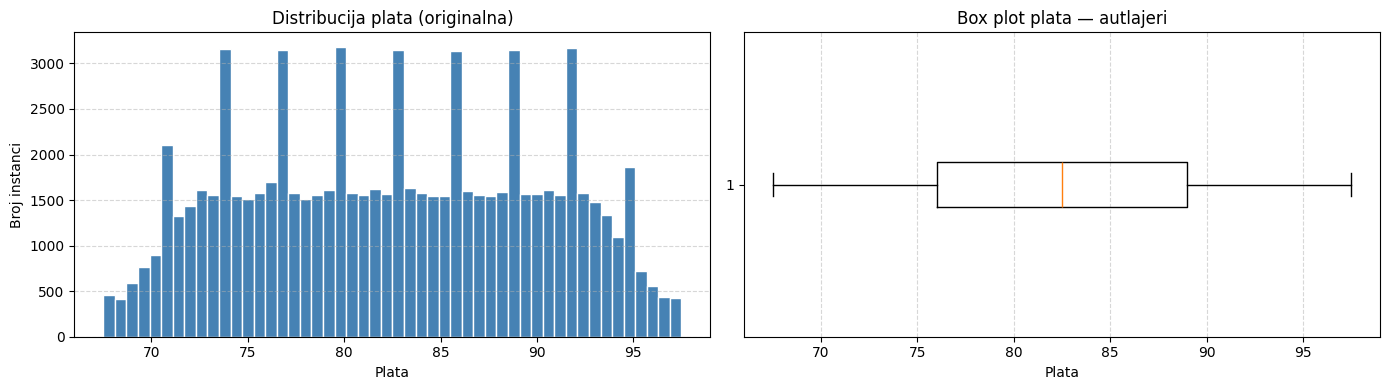

Min plata:    68
Max plata:    98
Srednja:      82
Medijana:     82
Std dev:      8

K-Means centroidi plata:
  Low: 74
  Medium: 82
  High: 91

K-Means distribucija:
salary_kmeans
Medium Salary    26869
Low Salary       26869
High Salary      26783
Name: count, dtype: int64

Kvantilna distribucija (stara metoda):
salary_clean
Medium Salary    26869
Low Salary       26869
High Salary      26783
Name: count, dtype: int64


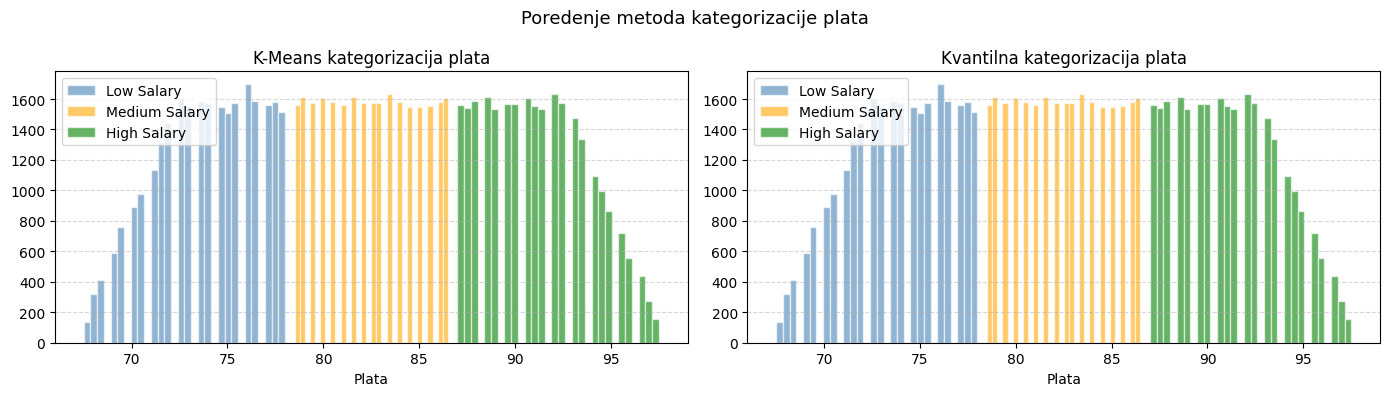


Balansiranost K-Means : 0.997
Balansiranost kvantila : 0.997

>>> Koristimo K-Means kategorizaciju


In [ ]:
from sklearn.cluster import KMeans

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_sample['salary_clean'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribucija plata (originalna)')
axes[0].set_xlabel('Plata')
axes[0].set_ylabel('Broj instanci')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].boxplot(df_sample['salary_clean'], vert=False)
axes[1].set_title('Box plot plata — autlajeri')
axes[1].set_xlabel('Plata')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Min plata:    {df_sample['salary_clean'].min():.0f}")
print(f"Max plata:    {df_sample['salary_clean'].max():.0f}")
print(f"Srednja:      {df_sample['salary_clean'].mean():.0f}")
print(f"Medijana:     {df_sample['salary_clean'].median():.0f}")
print(f"Std dev:      {df_sample['salary_clean'].std():.0f}")

kmeans_salary = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_salary.fit_predict(df_sample[['salary_clean']])

centroids = kmeans_salary.cluster_centers_.flatten()
sorted_idx = centroids.argsort()
label_map = {sorted_idx[0]: 'Low Salary', sorted_idx[1]: 'Medium Salary', sorted_idx[2]: 'High Salary'}
df_sample['salary_kmeans'] = [label_map[l] for l in kmeans_labels]

print(f"\nK-Means centroidi plata:")
for name, val in zip(['Low', 'Medium', 'High'], sorted(centroids)):
    print(f"  {name}: {val:.0f}")

print(f"\nK-Means distribucija:")
print(df_sample['salary_kmeans'].value_counts())

print(f"\nKvantilna distribucija (stara metoda):")
granica_niska_q  = df_sample['salary_clean'].quantile(0.33)
granica_visoka_q = df_sample['salary_clean'].quantile(0.66)
salary_q = df_sample['salary_clean'].apply(
    lambda x: 'Low Salary' if x <= granica_niska_q
              else ('Medium Salary' if x <= granica_visoka_q else 'High Salary')
)
print(salary_q.value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in zip(['Low Salary', 'Medium Salary', 'High Salary'], ['steelblue', 'orange', 'green']):
    subset = df_sample[df_sample['salary_kmeans'] == label]['salary_clean']
    axes[0].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0].set_title('K-Means kategorizacija plata')
axes[0].set_xlabel('Plata')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for label, color in zip(['Low Salary', 'Medium Salary', 'High Salary'], ['steelblue', 'orange', 'green']):
    subset = df_sample[salary_q == label]['salary_clean']
    axes[1].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
axes[1].set_title('Kvantilna kategorizacija plata')
axes[1].set_xlabel('Plata')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Poredenje metoda kategorizacije plata', fontsize=13)
plt.tight_layout()
plt.show()


kmeans_counts = df_sample['salary_kmeans'].value_counts()
kmeans_balance = kmeans_counts.min() / kmeans_counts.max()

quant_counts = salary_q.value_counts()
quant_balance = quant_counts.min() / quant_counts.max()

print(f"\nBalansiranost K-Means : {kmeans_balance:.3f}")
print(f"Balansiranost kvantila : {quant_balance:.3f}")

if kmeans_balance >= 0.7:
    use_kmeans = True
    print("\n>>> Koristimo K-Means kategorizaciju")
else:
    use_kmeans = False
    print("\n>>> Koristimo kvantilnu kategorizaciju")


In [ ]:
def kategorizuj_iskustvo(exp):
    if exp <= 5.5: return 'Junior-Intermediate'
    elif exp <= 8: return 'Mid-level'
    else: return 'Senior'

In [ ]:
df_sample['seniority'] = df_sample['exp_clean'].apply(kategorizuj_iskustvo)
le_seniority = LabelEncoder()
y_seniority = le_seniority.fit_transform(df_sample['seniority'])
print("Klase seniority:", le_seniority.classes_)

if use_kmeans:
    df_sample['salary_category'] = df_sample['salary_kmeans']
    print("\nSalary category: koristi K-Means klasterovanje")
else:
    granica_niska = df_sample['salary_clean'].quantile(0.33)
    granica_visoka = df_sample['salary_clean'].quantile(0.66)
    def kategorizuj_platu_tri(plata):
        if plata <= granica_niska: return 'Low Salary'
        elif plata <= granica_visoka: return 'Medium Salary'
        else: return 'High Salary'
    df_sample['salary_category'] = df_sample['salary_clean'].apply(kategorizuj_platu_tri)
    print("\nSalary category: koristi kvantilnu podelu")

print(df_sample['salary_category'].value_counts())

le_salary = LabelEncoder()
y_salary = le_salary.fit_transform(df_sample['salary_category'])
print(f"Klase salary: {le_salary.classes_}")

Klase seniority: ['Junior-Intermediate' 'Mid-level' 'Senior']

Salary category: koristi K-Means klasterovanje
salary_category
Medium Salary    26869
Low Salary       26869
High Salary      26783
Name: count, dtype: int64
Klase salary: ['High Salary' 'Low Salary' 'Medium Salary']


###  Cuvanje preprocesiranog skupa podataka

In [ ]:
cols_to_save = ['role', 'work type', 'responsibilities', 'experience', 'salary range',
                'combined_text', 'exp_clean', 'salary_clean', 'seniority', 'salary_category']
df_sample[cols_to_save].to_csv('/content/drive/MyDrive/IP2SkupoviPodataka/job_descriptions_preprocessed.csv', index=False)
print(f"Sacuvan preprocesirani skup: {df_sample[cols_to_save].shape}")
df_sample[cols_to_save].head()

Sacuvan preprocesirani skup: (80521, 10)


,role,work type,responsibilities,experience,salary range,combined_text,exp_clean,salary_clean,seniority,salary_category
330351,API Developer,Part-Time,Design and implement APIs (Application Program...,1 to 12 Years,$64K-$109K,design and implement apis (application program...,6.5,86.5,Mid-level,Medium Salary
210046,API Developer,Intern,Design and implement APIs (Application Program...,4 to 8 Years,$56K-$82K,design and implement apis (application program...,6.0,69.0,Mid-level,Low Salary
885439,API Developer,Intern,Design and implement APIs (Application Program...,4 to 11 Years,$61K-$121K,design and implement apis (application program...,7.5,91.0,Mid-level,High Salary
742577,API Developer,Full-Time,Design and implement APIs (Application Program...,3 to 9 Years,$61K-$124K,design and implement apis (application program...,6.0,92.5,Mid-level,High Salary
1150117,API Developer,Part-Time,Design and implement APIs (Application Program...,2 to 11 Years,$60K-$101K,design and implement apis (application program...,6.5,80.5,Mid-level,Medium Salary


##  Analiza uticaja broja TF-IDF reci — Logistic Regression

In [ ]:
targets = {
    "Job Role":        y,
    "Work Type":       y_work,
    "Seniority":       y_seniority,
    "Salary Category": y_salary
}

In [ ]:
tfidf_pca = TfidfVectorizer(max_features=15, stop_words='english')
X_text_pca = tfidf_pca.fit_transform(df_sample['combined_text']).toarray()
scaler_pca = MinMaxScaler()
num_pca = scaler_pca.fit_transform(num_features_raw)
X_final_pca = np.hstack((X_text_pca, num_pca))

### 2D PCA vizualizacija — svi targeti

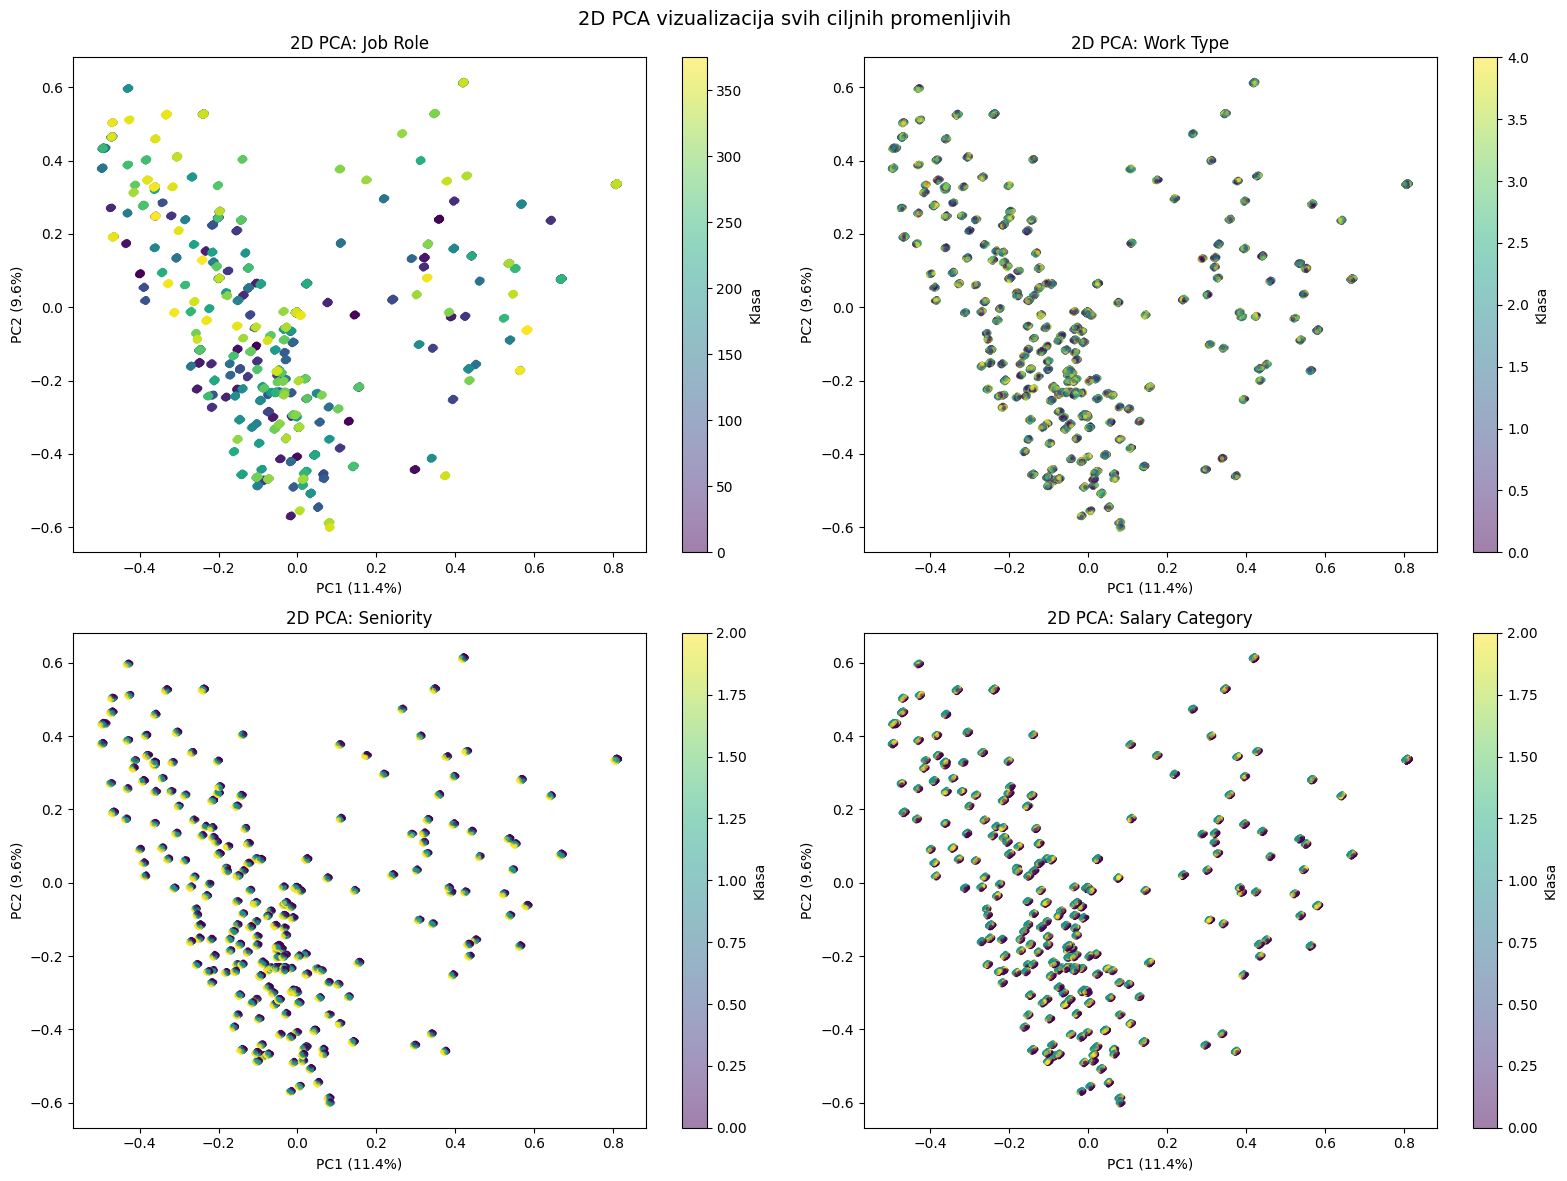

Objasnjena varijansa: PC1=11.36%, PC2=9.56%


In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_final_pca)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (target_name, target_values) in enumerate(targets.items()):
    sc = axes[idx].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=target_values, cmap='viridis',
                           alpha=0.5, s=10, edgecolors='none')
    axes[idx].set_title(f'2D PCA: {target_name}', fontsize=12)
    axes[idx].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    axes[idx].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    plt.colorbar(sc, ax=axes[idx], label='Klasa')

plt.suptitle('2D PCA vizualizacija svih ciljnih promenljivih', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Objasnjena varijansa: PC1={pca_2d.explained_variance_ratio_[0]*100:.2f}%, "
      f"PC2={pca_2d.explained_variance_ratio_[1]*100:.2f}%")

Broj reci: 10 -> Tacnost: 0.4278
Broj reci: 12 -> Tacnost: 0.5549
Broj reci: 14 -> Tacnost: 0.6357
Broj reci: 16 -> Tacnost: 0.6998
Broj reci: 18 -> Tacnost: 0.7440
Broj reci: 20 -> Tacnost: 0.7793


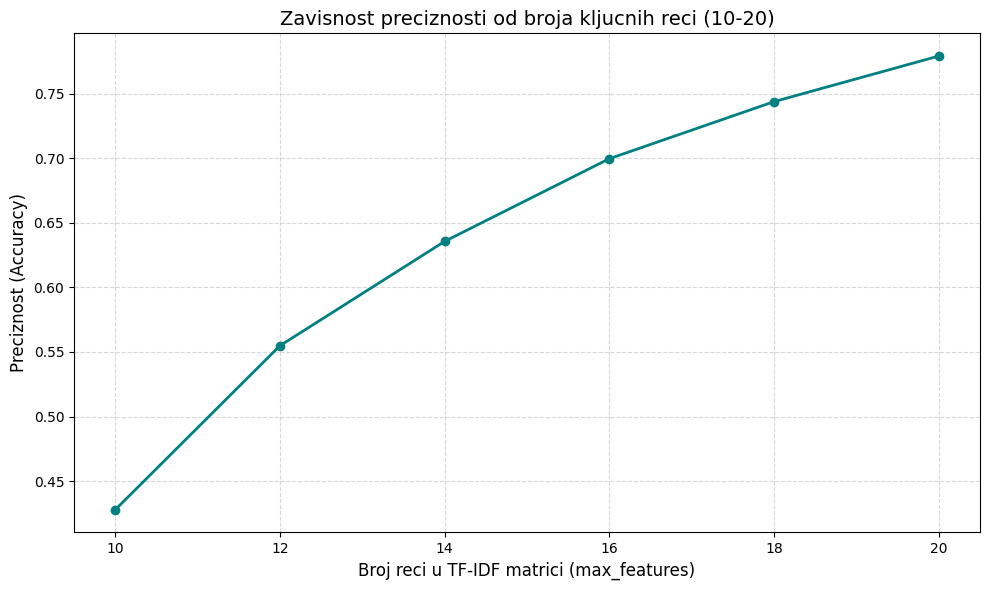

In [ ]:
broj_reci_lista = list(range(10, 21, 2))
tacnosti = []

X_train_text, X_test_text, X_train_num_raw, X_test_num_raw, y_train_l, y_test_l = train_test_split(
    df_sample['combined_text'], num_features_raw, y, test_size=0.2, random_state=42, stratify=y
)
#Koristimo minMaxScaler da bismo videli kako broj reci utice na tacnost, kasnije za sve modele cemo koristiti bolji scaler
scaler_lr = MinMaxScaler()
X_train_num = scaler_lr.fit_transform(X_train_num_raw)
X_test_num = scaler_lr.transform(X_test_num_raw)

for n in broj_reci_lista:
    tfidf_loop = TfidfVectorizer(max_features=n, stop_words='english')
    X_train_tfidf = tfidf_loop.fit_transform(X_train_text).toarray()
    X_test_tfidf = tfidf_loop.transform(X_test_text).toarray()
    X_train_l = np.hstack((X_train_tfidf, X_train_num))
    X_test_l = np.hstack((X_test_tfidf, X_test_num))
    test_model = LogisticRegression(max_iter=1000)
    test_model.fit(X_train_l, y_train_l)
    acc = test_model.score(X_test_l, y_test_l)
    tacnosti.append(acc)
    print(f"Broj reci: {n} -> Tacnost: {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(broj_reci_lista, tacnosti, marker='o', linestyle='-', color='teal', linewidth=2)
plt.title('Zavisnost preciznosti od broja kljucnih reci (10-20)', fontsize=14)
plt.xlabel('Broj reci u TF-IDF matrici (max_features)', fontsize=12)
plt.ylabel('Preciznost (Accuracy)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(broj_reci_lista)
plt.tight_layout()
plt.show()

## Analiza kriterijuma — Decision Tree

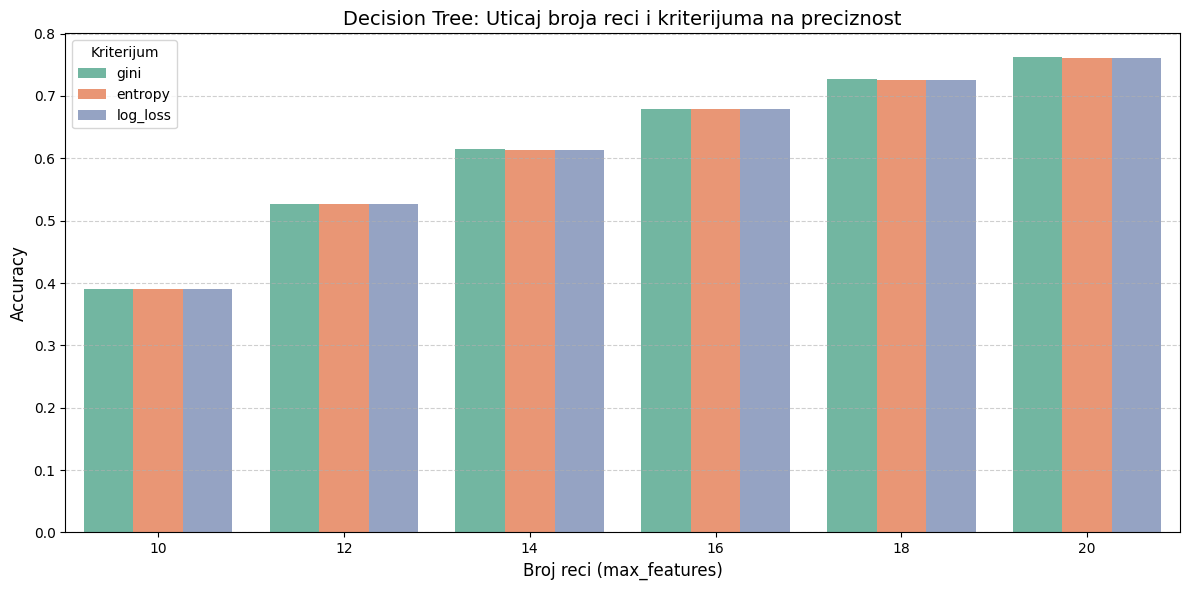

In [ ]:
kriterijumi = ['gini', 'entropy', 'log_loss']
dt_rezultati = []

X_train_text, X_test_text, X_train_num_raw, X_test_num_raw, y_train_dt, y_test_dt = train_test_split(
    df_sample['combined_text'], num_features_raw, y, test_size=0.2, random_state=42, stratify=y
)
#Ovde radimo analizu koje kriterijumi su najbolji za DT klasifikator, pa cemo te parametre koristiti u okviru modela
scaler_dt = MinMaxScaler()
X_train_num = scaler_dt.fit_transform(X_train_num_raw)
X_test_num = scaler_dt.transform(X_test_num_raw)

for n in broj_reci_lista:
    tfidf_dt = TfidfVectorizer(max_features=n, stop_words='english')
    X_train_tfidf = tfidf_dt.fit_transform(X_train_text).toarray()
    X_test_tfidf = tfidf_dt.transform(X_test_text).toarray()
    X_train_dt = np.hstack((X_train_tfidf, X_train_num))
    X_test_dt = np.hstack((X_test_tfidf, X_test_num))
    for crit in kriterijumi:
        model_dt = DecisionTreeClassifier(criterion=crit, random_state=42)
        model_dt.fit(X_train_dt, y_train_dt)
        acc = model_dt.score(X_test_dt, y_test_dt)
        dt_rezultati.append({'Broj_reci': n, 'Kriterijum': crit, 'Accuracy': acc})

df_dt_analiza = pd.DataFrame(dt_rezultati)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_dt_analiza, x='Broj_reci', y='Accuracy', hue='Kriterijum', palette='Set2')
plt.title('Decision Tree: Uticaj broja reci i kriterijuma na preciznost', fontsize=14)
plt.xlabel('Broj reci (max_features)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(title='Kriterijum')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Optimizacija hiperparametara — GridSearchCV

GridSearchCV sa 5-fold CV za Decision Tree i KNN na Job Role targetu (najzahtevniji). Optimalni parametri se zatim koriste u finalnom `classifiers` recniku.

7.5 Poredenje skalera — MinMaxScaler vs StandardScaler
Testiramo uticaj izbora skalera na tacnost svih 5 algoritama, za sve 4 ciljne promenljive.

In [ ]:
targets = {
    "Job Role":        y,
    "Work Type":       y_work,
    "Seniority":       y_seniority,
    "Salary Category": y_salary
}

encoders = {
    "Job Role":        le,
    "Work Type":       le_work,
    "Seniority":       le_seniority,
    "Salary Category": le_salary
}

target_key_map = {
    "Job Role":        "role",
    "Work Type":       "work_type",
    "Seniority":       "seniority",
    "Salary Category": "salary_category"
}

print("--- MAPIRANJE KLASA (Broj -> Naziv) ---")
for name, encoder in encoders.items():
    print(f"\nTarget: {name}")
    for i, label in enumerate(encoder.classes_):
        print(f"  {i} : {label}")

--- MAPIRANJE KLASA (Broj -> Naziv) ---

Target: Job Role
  0 : API Developer
  1 : Accessibility Developer
  2 : Account Executive
  3 : Account Manager
  4 : Account Strategist
  5 : Accounting Controller
  6 : Accounting Manager
  7 : Acute Care Nurse Practitioner
  8 : Addiction Counselor
  9 : Administrative Assistant
  10 : Administrative Coordinator
  11 : Administrative Manager
  12 : Adult Speech Therapist
  13 : Advertising Account Executive
  14 : Agile Product Owner
  15 : Agile Project Manager
  16 : Aircraft Design Engineer
  17 : Analytical Chemist
  18 : Architectural Designer
  19 : Architectural Drafter
  20 : Art Curator
  21 : Art Education Coordinator
  22 : Automation Test Engineer
  23 : Automation Tester
  24 : Avionics Engineer
  25 : B2B Sales Consultant
  26 : Backend Developer
  27 : Backend Web Developer
  28 : Benefits Coordinator
  29 : Big Data Engineer
  30 : Brand Director
  31 : Brand Manager
  32 : Brand Marketing Analyst
  33 : Brand PR Specialist
 

In [ ]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":        DecisionTreeClassifier(random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN":                  KNeighborsClassifier(), #
    "Naive Bayes":          GaussianNB()
}

print("Klasifikatori azurirani sa optimalnim parametrima:")
for name, clf in classifiers.items():
    print(f"  {name}: {clf.get_params()}")


Klasifikatori azurirani sa optimalnim parametrima:
  Logistic Regression: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
  Decision Tree: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
  Random Forest: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_est

In [ ]:
from sklearn.preprocessing import StandardScaler

best_scaler = MinMaxScaler()
best_scaler_name = 'MinMaxScaler'


=== Job Role ===


Scaler,MinMaxScaler,StandardScaler,Razlika (Std - MM)
Algorithm,,,
Logistic Regression,0.6552,0.6559,0.0007
Naive Bayes,0.6555,0.6555,0.0000
Decision Tree,0.6341,0.6337,-0.0004
Random Forest,0.6373,0.6366,-0.0007
KNN,0.6404,0.6244,-0.0160


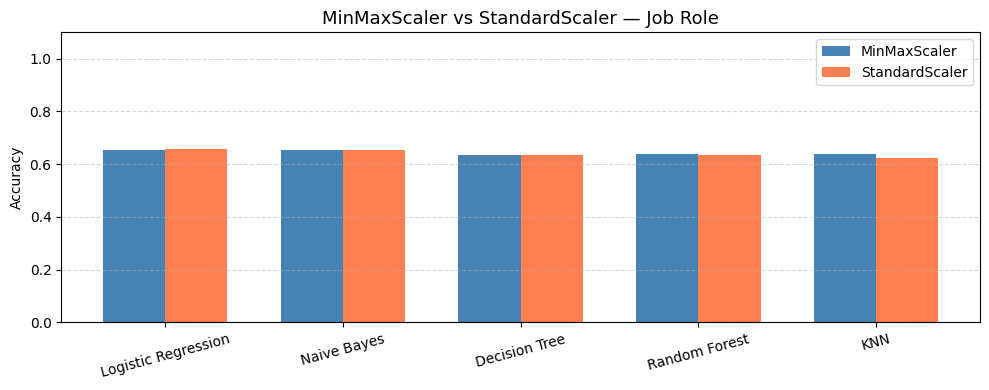


=== Work Type ===


Scaler,MinMaxScaler,StandardScaler,Razlika (Std - MM)
Algorithm,,,
KNN,0.2015,0.2026,0.0011
Naive Bayes,0.1986,0.1986,0.0000
Logistic Regression,0.2030,0.2028,-0.0002
Decision Tree,0.2046,0.2040,-0.0006
Random Forest,0.2021,0.2007,-0.0014


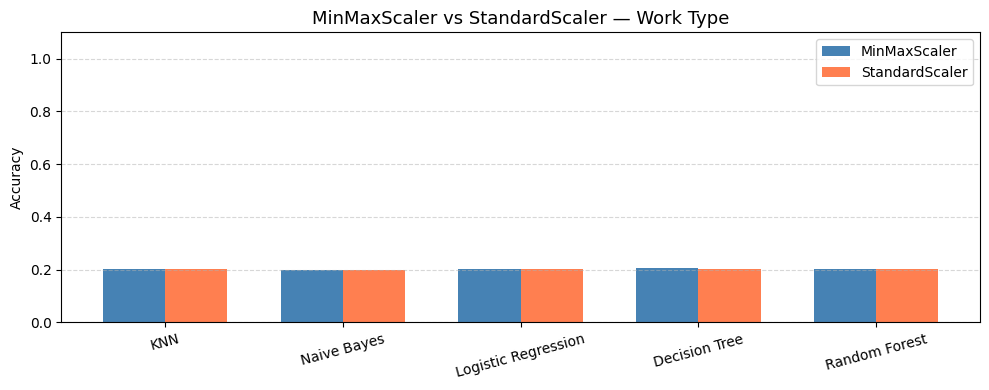


=== Seniority ===


Scaler,MinMaxScaler,StandardScaler,Razlika (Std - MM)
Algorithm,,,
Logistic Regression,0.5829,0.5829,0.0000
Random Forest,0.5121,0.5121,0.0000
Naive Bayes,0.5829,0.5829,0.0000
Decision Tree,0.5004,0.5003,-0.0001
KNN,0.4859,0.4849,-0.0010


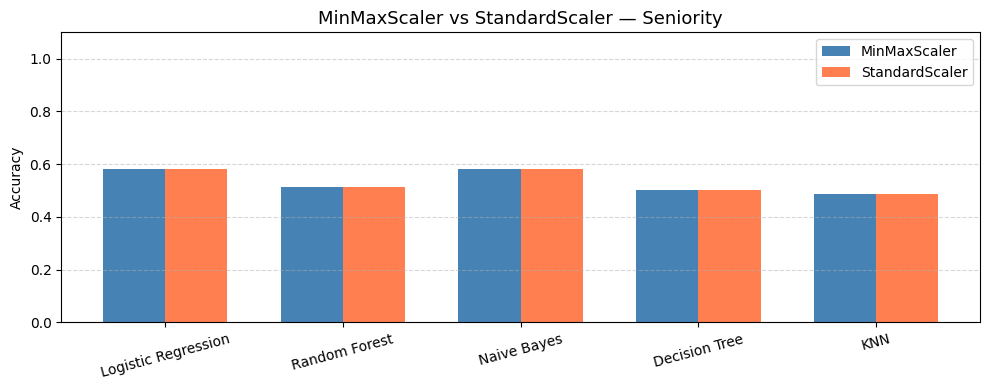


=== Salary Category ===


Scaler,MinMaxScaler,StandardScaler,Razlika (Std - MM)
Algorithm,,,
Decision Tree,0.3408,0.3408,0.0000
Random Forest,0.3364,0.3364,0.0000
Naive Bayes,0.3349,0.3349,0.0000
Logistic Regression,0.3371,0.3368,-0.0003
KNN,0.3390,0.3385,-0.0005


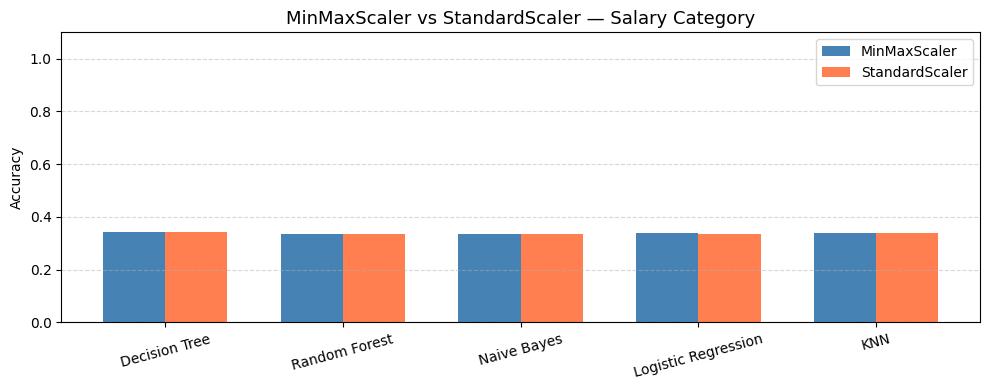


=== ZBIRNA TABELA — prosek po svim targetima ===


Scaler,MinMaxScaler,StandardScaler,Razlika (Std - MM),Bolji scaler
Algorithm,,,,
Logistic Regression,0.4446,0.4446,0.0000,Jednako
Naive Bayes,0.4430,0.4430,0.0000,Jednako
Decision Tree,0.4200,0.4197,-0.0003,MinMaxScaler
Random Forest,0.4220,0.4214,-0.0006,MinMaxScaler
KNN,0.4167,0.4126,-0.0041,MinMaxScaler



>>> Izabrani scaler za glavni pipeline: MinMaxScaler
    MinMaxScaler prosek:   0.4293
    StandardScaler prosek: 0.4283
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
from sklearn.preprocessing import StandardScaler

scalers = {
    'MinMaxScaler':   MinMaxScaler(),
    'StandardScaler': StandardScaler()
}

scaler_results = []

tfidf_sc = TfidfVectorizer(max_features=15, stop_words='english')

num_map = {
    'Job Role':        num_features_raw,
    'Work Type':       num_features_raw,
    'Seniority':       num_features_no_exp,
    'Salary Category': num_features_no_sal
}

for target_name, target_values in targets.items():

    X_train_text_sc, X_test_text_sc, X_train_num_sc, X_test_num_sc, y_train_sc, y_test_sc = train_test_split(
        df_sample['combined_text'], num_map[target_name], target_values,
        test_size=0.2, random_state=42, stratify=target_values
    )

    X_train_tfidf_sc = tfidf_sc.fit_transform(X_train_text_sc).toarray()
    X_test_tfidf_sc  = tfidf_sc.transform(X_test_text_sc).toarray()

    for scaler_name, scaler_obj in scalers.items():
        X_train_num_scaled = scaler_obj.fit_transform(X_train_num_sc)
        X_test_num_scaled  = scaler_obj.transform(X_test_num_sc)

        X_train_sc_final = np.hstack((X_train_tfidf_sc, X_train_num_scaled))
        X_test_sc_final  = np.hstack((X_test_tfidf_sc,  X_test_num_scaled))

        for clf_name, clf in classifiers.items():
            clf.fit(X_train_sc_final, y_train_sc)
            acc = clf.score(X_test_sc_final, y_test_sc)
            scaler_results.append({
                'Target':    target_name,
                'Scaler':    scaler_name,
                'Algorithm': clf_name,
                'Accuracy':  round(acc, 4)
            })

df_scalers = pd.DataFrame(scaler_results)

for target_name in targets.keys():
    subset = df_scalers[df_scalers['Target'] == target_name]
    pivot = subset.pivot(index='Algorithm', columns='Scaler', values='Accuracy').round(4)
    pivot['Razlika (Std - MM)'] = (pivot['StandardScaler'] - pivot['MinMaxScaler']).round(4)
    pivot = pivot.sort_values('Razlika (Std - MM)', ascending=False)

    print(f"\n=== {target_name} ===")
    display(pivot)

    plt.figure(figsize=(10, 4))
    x = np.arange(len(pivot))
    width = 0.35
    plt.bar(x - width/2, pivot['MinMaxScaler'],   width, label='MinMaxScaler',   color='steelblue')
    plt.bar(x + width/2, pivot['StandardScaler'], width, label='StandardScaler', color='coral')
    plt.xticks(x, pivot.index, rotation=15)
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.1)
    plt.title(f'MinMaxScaler vs StandardScaler — {target_name}', fontsize=13)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

df_avg = df_scalers.groupby(['Algorithm', 'Scaler'])['Accuracy'].mean().unstack().round(4)
df_avg['Razlika (Std - MM)'] = (df_avg['StandardScaler'] - df_avg['MinMaxScaler']).round(4)
df_avg['Bolji scaler'] = df_avg['Razlika (Std - MM)'].apply(
    lambda x: 'StandardScaler' if x > 0 else ('MinMaxScaler' if x < 0 else 'Jednako')
)
df_avg = df_avg.sort_values('Razlika (Std - MM)', ascending=False)

print("\n=== ZBIRNA TABELA — prosek po svim targetima ===")
display(df_avg)

mm_avg  = df_avg['MinMaxScaler'].mean()
std_avg = df_avg['StandardScaler'].mean()

if std_avg > mm_avg:
    best_scaler      = StandardScaler()
    best_scaler_name = 'StandardScaler'
else:
    best_scaler      = MinMaxScaler()
    best_scaler_name = 'MinMaxScaler'

print(f"\n>>> Izabrani scaler za glavni pipeline: {best_scaler_name}")
print(f"    MinMaxScaler prosek:   {mm_avg:.4f}")
print(f"    StandardScaler prosek: {std_avg:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Najbolji DT parametri: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 5}
Najbolja CV tacnost:   0.6392
Test tacnost:          0.6397


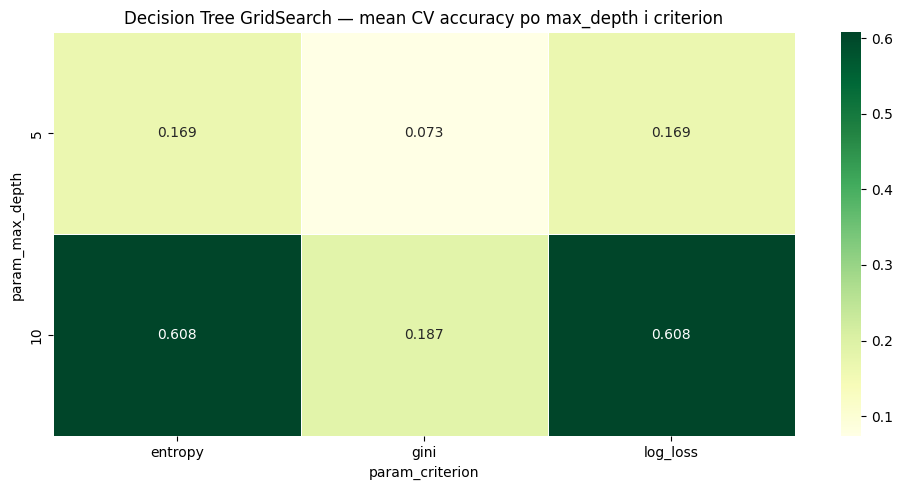

In [ ]:
from sklearn.model_selection import GridSearchCV

X_train_text_gs, X_test_text_gs, X_train_num_gs, X_test_num_gs, y_train_gs, y_test_gs = train_test_split(
    df_sample['combined_text'], num_features_raw, y,
    test_size=0.2, random_state=42, stratify=y
)

tfidf_gs = TfidfVectorizer(max_features=15, stop_words='english')
X_train_tfidf_gs = tfidf_gs.fit_transform(X_train_text_gs).toarray()
X_test_tfidf_gs  = tfidf_gs.transform(X_test_text_gs).toarray()

scaler_gs = best_scaler
X_train_num_gs = scaler_gs.fit_transform(X_train_num_gs)
X_test_num_gs  = scaler_gs.transform(X_test_num_gs)

X_train_gs = np.hstack((X_train_tfidf_gs, X_train_num_gs))
X_test_gs  = np.hstack((X_test_tfidf_gs,  X_test_num_gs))

param_grid_dt = {
    'max_depth':        [5, 10,  None],
    'min_samples_leaf': [1, 5],
    'criterion':        ['gini', 'entropy', 'log_loss']
}
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
gs_dt.fit(X_train_gs, y_train_gs)

best_dt_params = gs_dt.best_params_
best_dt_score  = gs_dt.best_score_
print(f"\nNajbolji DT parametri: {best_dt_params}")
print(f"Najbolja CV tacnost:   {best_dt_score:.4f}")
print(f"Test tacnost:          {gs_dt.best_estimator_.score(X_test_gs, y_test_gs):.4f}")

dt_results_df = pd.DataFrame(gs_dt.cv_results_)
dt_pivot = dt_results_df.groupby(['param_max_depth', 'param_criterion'])['mean_test_score'].max().unstack()
plt.figure(figsize=(10, 5))
sns.heatmap(dt_pivot, annot=True, fmt='.3f', cmap='YlGn', linewidths=0.5)
plt.title('Decision Tree GridSearch — mean CV accuracy po max_depth i criterion', fontsize=12)
plt.tight_layout()
plt.show()


GridSearch — KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Najbolji KNN parametri: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Najbolja CV tacnost:    0.6487
Test tacnost:           0.6497


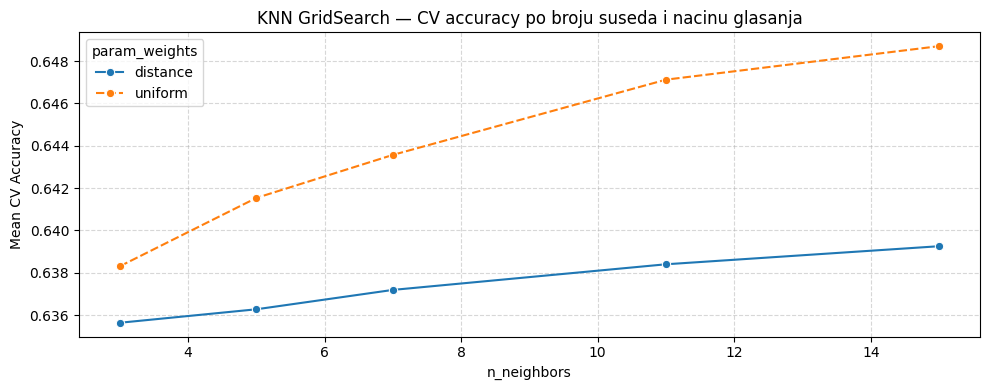

In [ ]:
print("\nGridSearch — KNN...")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}
gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
gs_knn.fit(X_train_gs, y_train_gs)

best_knn_params = gs_knn.best_params_
best_knn_score  = gs_knn.best_score_
print(f"\nNajbolji KNN parametri: {best_knn_params}")
print(f"Najbolja CV tacnost:    {best_knn_score:.4f}")
print(f"Test tacnost:           {gs_knn.best_estimator_.score(X_test_gs, y_test_gs):.4f}")

knn_results_df = pd.DataFrame(gs_knn.cv_results_)
knn_pivot = knn_results_df.groupby(['param_n_neighbors', 'param_weights'])['mean_test_score'].max().unstack()
plt.figure(figsize=(10, 4))
sns.lineplot(data=knn_pivot, marker='o')
plt.title('KNN GridSearch — CV accuracy po broju suseda i nacinu glasanja', fontsize=12)
plt.xlabel('n_neighbors')
plt.ylabel('Mean CV Accuracy')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(gs_dt.best_estimator_,  '/content/drive/MyDrive/IP2_modeli_parametri_v2/best_decision_tree.pkl')
joblib.dump(gs_knn.best_estimator_, '/content/drive/MyDrive/IP2_modeli_parametri_v2/best_knn.pkl')
print("\nNajbolji DT i KNN modeli sacuvani na Drive-u.")


Najbolji DT i KNN modeli sacuvani na Drive-u.


In [ ]:
classifiers_best = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":        DecisionTreeClassifier(random_state=42, **best_dt_params),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN":                  KNeighborsClassifier(**best_knn_params),
    "Naive Bayes":          GaussianNB()
}

In [ ]:
import time

In [ ]:
import os
import joblib

save_dir = '/content/drive/MyDrive/modeli_V2'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(le,           f'{save_dir}/label_encoder_role.pkl')
joblib.dump(le_work,      f'{save_dir}/label_encoder_work_type.pkl')
joblib.dump(le_seniority, f'{save_dir}/label_encoder_seniority.pkl')
joblib.dump(le_salary,    f'{save_dir}/label_encoder_salary.pkl')

all_results  = []
all_f1       = []
all_times    = []

In [ ]:
num_map = {
    'Job Role':        num_features_raw,
    'Work Type':       num_features_raw,
    'Seniority':       num_features_no_exp,
    'Salary Category': num_features_no_sal
}

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

tfidf_final = TfidfVectorizer(max_features=15, stop_words='english')
scaler = best_scaler
print(f"Koristimo scaler: {best_scaler_name}")

for target_name, target_values in targets.items():
    target_key = target_key_map[target_name]
    encoder    = encoders[target_name]

    X_train_text, X_test_text, X_train_num_raw, X_test_num_raw, y_train, y_test = train_test_split(
        df_sample['combined_text'], num_map[target_name], target_values,
        test_size=0.2, random_state=42, stratify=target_values
    )

    X_train_tfidf = tfidf_final.fit_transform(X_train_text).toarray()
    X_test_tfidf  = tfidf_final.transform(X_test_text).toarray()
    X_train_num   = scaler.fit_transform(X_train_num_raw)
    X_test_num    = scaler.transform(X_test_num_raw)

    X_train = np.hstack((X_train_tfidf, X_train_num))
    X_test  = np.hstack((X_test_tfidf, X_test_num))

    joblib.dump(tfidf_final, f'{save_dir}/tfidf_{target_key}.pkl')
    joblib.dump(scaler,      f'{save_dir}/scaler_{target_key}.pkl')

    print(f"\nTARGET: {target_name}...")

    for name, model in classifiers_best.items():
        t_start = time.time()
        model.fit(X_train, y_train)
        t_train = time.time() - t_start

        y_pred   = model.predict(X_test)
        accuracy = model.score(X_test, y_test)

        report_dict = classification_report(y_test, y_pred, target_names=encoder.classes_, output_dict=True, zero_division=0)
        macro_f1 = report_dict['macro avg']['f1-score']

        res_entry = {"Target": target_name, "Algorithm": name, "Accuracy": accuracy, "Macro F1": macro_f1, "Train time (s)": t_train}
        all_results.append(res_entry)

        safe_name = name.replace(' ', '_').lower()
        joblib.dump(model, f'{save_dir}/model_{safe_name}_{target_key}.pkl')

Koristimo scaler: MinMaxScaler

TARGET: Job Role...

TARGET: Work Type...

TARGET: Seniority...

TARGET: Salary Category...



=== RANG TABELA: Job Role ===


,Algorithm,Accuracy,Macro F1,Train time (s)
0,Random Forest,0.637256,0.603105,27.732085
1,Decision Tree,0.639739,0.601521,0.400391
2,KNN,0.649736,0.599449,0.012293
3,Naive Bayes,0.655511,0.581786,0.073020
4,Logistic Regression,0.655200,0.577346,33.312696


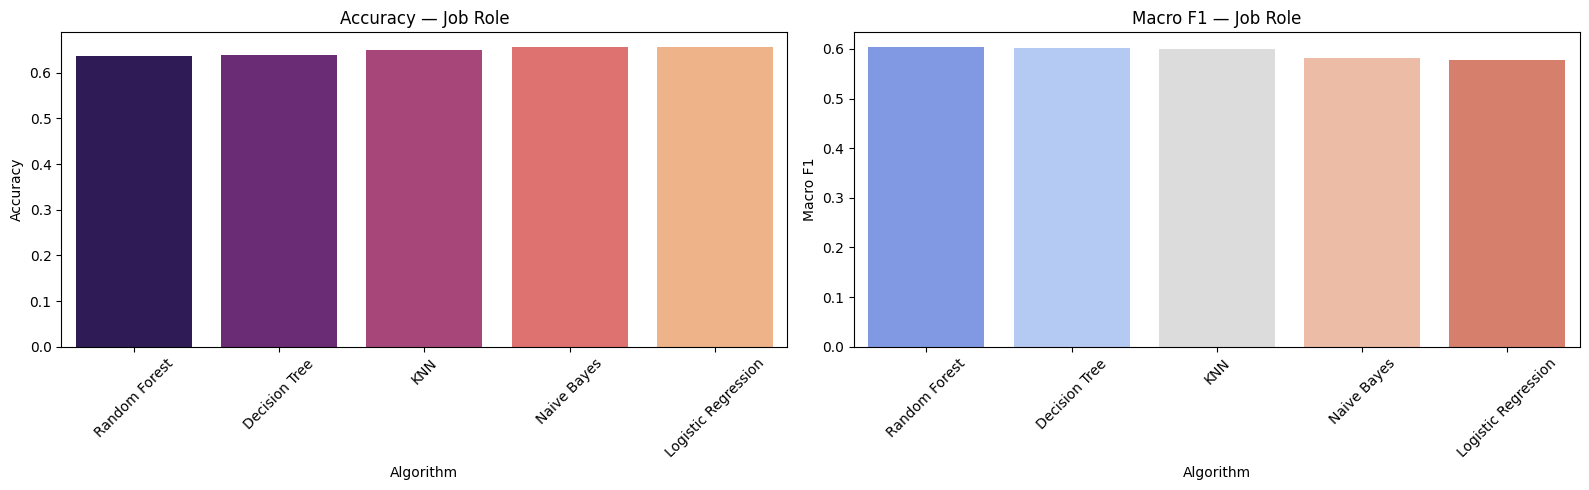


=== RANG TABELA: Work Type ===


,Algorithm,Accuracy,Macro F1,Train time (s)
0,Random Forest,0.202111,0.202054,14.405586
1,Logistic Regression,0.202980,0.201520,0.310897
2,Naive Bayes,0.198634,0.197652,0.032248
3,KNN,0.197951,0.195071,0.003834
4,Decision Tree,0.196212,0.194088,0.395735


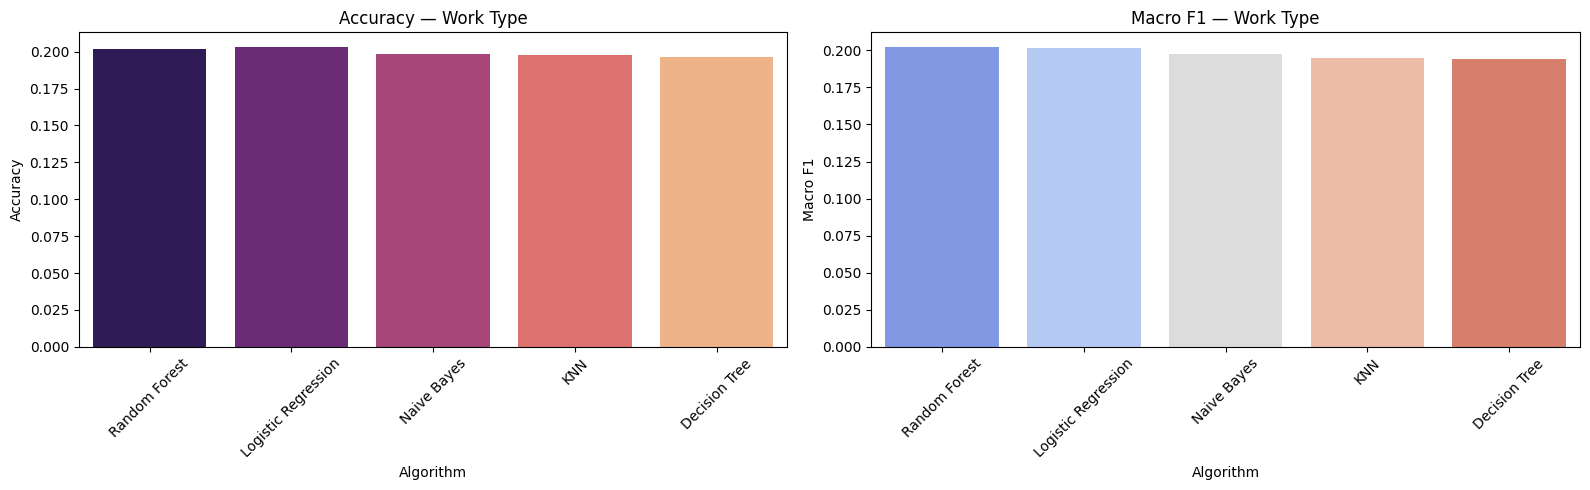


=== RANG TABELA: Seniority ===


,Algorithm,Accuracy,Macro F1,Train time (s)
0,Random Forest,0.512077,0.315959,7.195723
1,Decision Tree,0.518969,0.307317,0.245135
2,KNN,0.553927,0.275841,0.004085
3,Logistic Regression,0.582862,0.245489,0.336400
4,Naive Bayes,0.582862,0.245489,0.019032


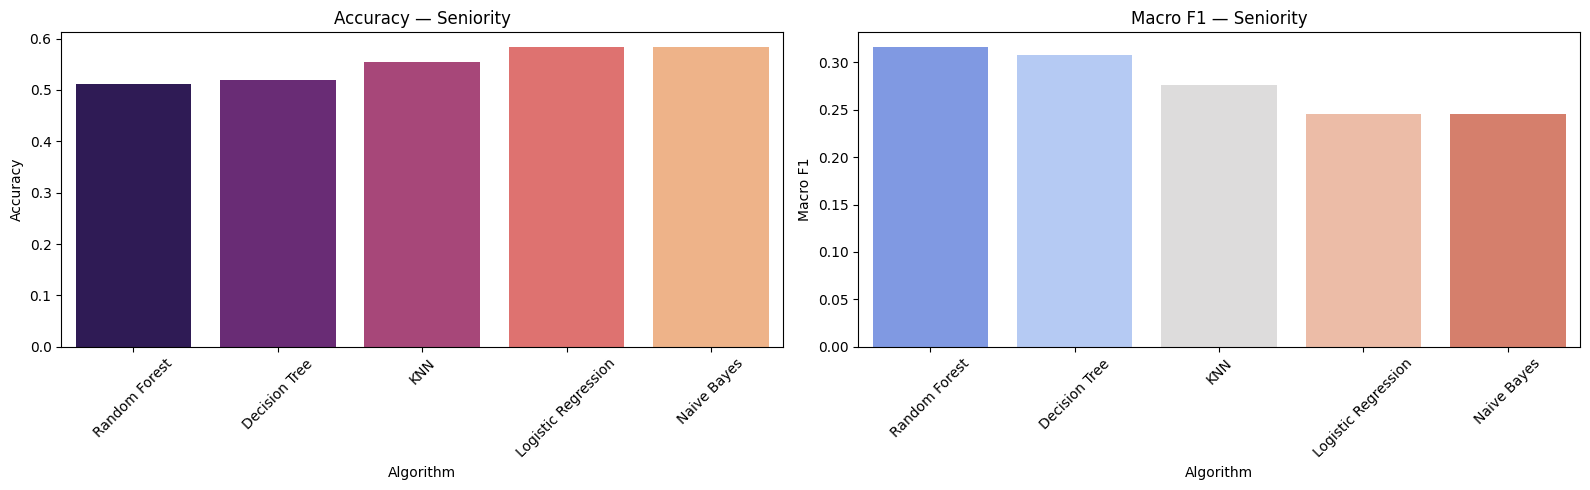


=== RANG TABELA: Salary Category ===


,Algorithm,Accuracy,Macro F1,Train time (s)
0,Decision Tree,0.341136,0.339290,0.245928
1,Logistic Regression,0.337100,0.336490,0.185905
2,Random Forest,0.336355,0.336321,6.119705
3,Naive Bayes,0.334927,0.333805,0.022657
4,KNN,0.334617,0.333242,0.007188


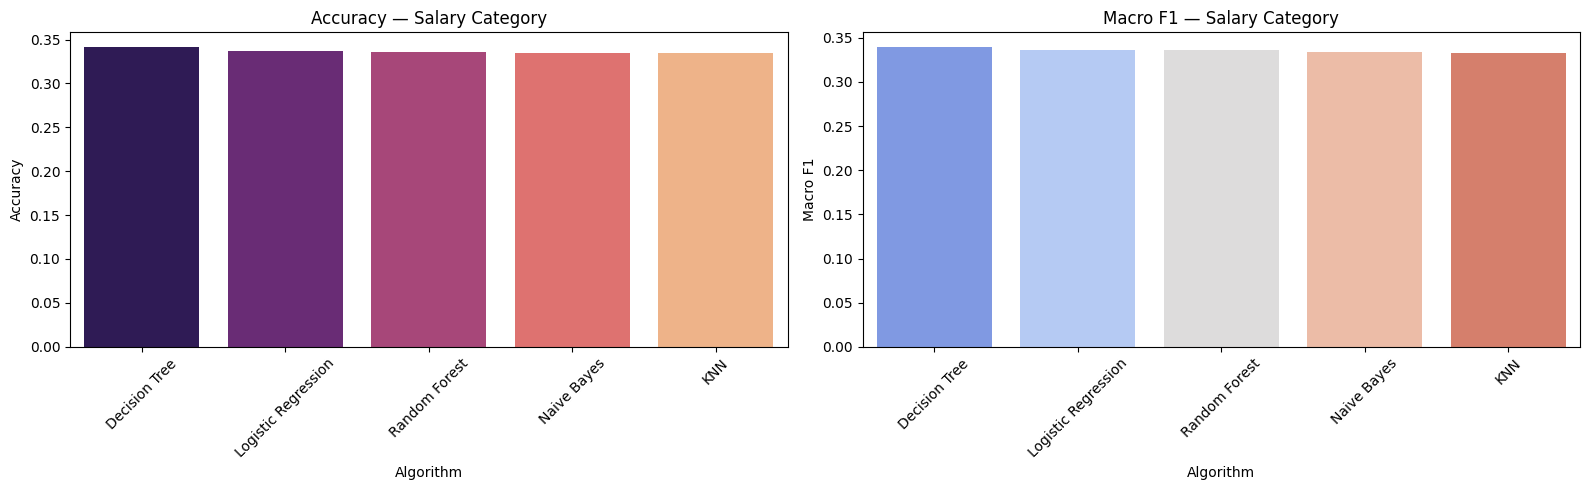

In [ ]:
df_all_results = pd.DataFrame(all_results)

for target_name in targets.keys():
    df_target = df_all_results[df_all_results['Target'] == target_name].sort_values('Macro F1', ascending=False)

    print(f"\n=== RANG TABELA: {target_name} ===")
    display(df_target.drop(columns='Target').reset_index(drop=True))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(x='Algorithm', y='Accuracy', data=df_target, palette='magma', ax=ax1)
    ax1.set_title(f'Accuracy — {target_name}')
    ax1.tick_params(axis='x', rotation=45)

    sns.barplot(x='Algorithm', y='Macro F1', data=df_target, palette='coolwarm', ax=ax2)
    ax2.set_title(f'Macro F1 — {target_name}')
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

### Zbirne tabele — Accuracy, Macro F1 i vreme treniranja

=== ZBIRNA TABELA — Accuracy ===


Target,Job Role,Salary Category,Seniority,Work Type,Prosek
Algorithm,,,,,
Logistic Regression,0.6552,0.3371,0.5829,0.2030,0.4445
Naive Bayes,0.6555,0.3349,0.5829,0.1986,0.4430
KNN,0.6497,0.3346,0.5539,0.1980,0.4341
Decision Tree,0.6397,0.3411,0.5190,0.1962,0.4240
Random Forest,0.6373,0.3364,0.5121,0.2021,0.4219


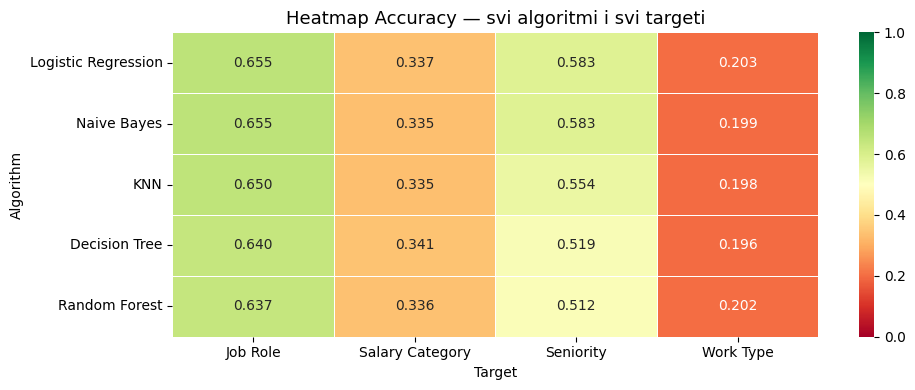


=== ZBIRNA TABELA — Macro F1 ===


Target,Job Role,Salary Category,Seniority,Work Type,Prosek
Algorithm,,,,,
Random Forest,0.6031,0.3363,0.3160,0.2021,0.3644
Decision Tree,0.6015,0.3393,0.3073,0.1941,0.3606
KNN,0.5994,0.3332,0.2758,0.1951,0.3509
Logistic Regression,0.5773,0.3365,0.2455,0.2015,0.3402
Naive Bayes,0.5818,0.3338,0.2455,0.1977,0.3397


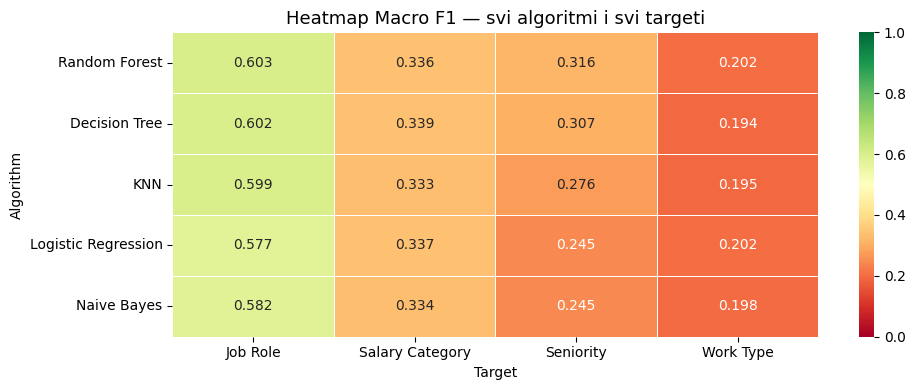


=== ZBIRNA TABELA — Vreme treniranja (s) ===


Target,Job Role,Salary Category,Seniority,Work Type,Prosek
Algorithm,,,,,
KNN,0.012,0.007,0.004,0.004,0.007
Naive Bayes,0.073,0.023,0.019,0.032,0.037
Decision Tree,0.400,0.246,0.245,0.396,0.322
Logistic Regression,33.313,0.186,0.336,0.311,8.536
Random Forest,27.732,6.120,7.196,14.406,13.863


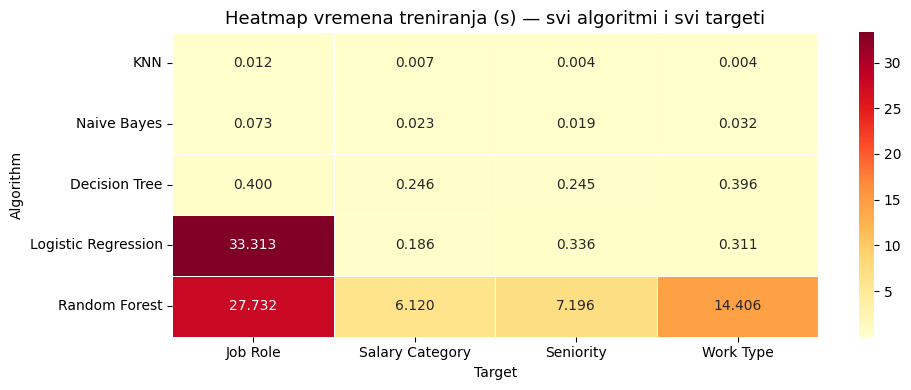

In [ ]:
df_master = pd.DataFrame(all_results)

pivot_acc = df_master.pivot(index='Algorithm', columns='Target', values='Accuracy')
pivot_acc['Prosek'] = pivot_acc.mean(axis=1)
pivot_acc = pivot_acc.sort_values('Prosek', ascending=False).round(4)

print("=== ZBIRNA TABELA — Accuracy ===")
display(pivot_acc)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_acc.drop(columns='Prosek'), annot=True, fmt='.3f',
            cmap='RdYlGn', linewidths=0.5, vmin=0, vmax=1)
plt.title('Heatmap Accuracy — svi algoritmi i svi targeti', fontsize=13)
plt.tight_layout()
plt.show()

pivot_f1 = df_master.pivot(index='Algorithm', columns='Target', values='Macro F1')
pivot_f1['Prosek'] = pivot_f1.mean(axis=1)
pivot_f1 = pivot_f1.sort_values('Prosek', ascending=False).round(4)

print("\n=== ZBIRNA TABELA — Macro F1 ===")
display(pivot_f1)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_f1.drop(columns='Prosek'), annot=True, fmt='.3f',
            cmap='RdYlGn', linewidths=0.5, vmin=0, vmax=1)
plt.title('Heatmap Macro F1 — svi algoritmi i svi targeti', fontsize=13)
plt.tight_layout()
plt.show()

pivot_time = df_master.pivot(index='Algorithm', columns='Target', values='Train time (s)')
pivot_time['Prosek'] = pivot_time.mean(axis=1)
pivot_time = pivot_time.sort_values('Prosek', ascending=True).round(3)

print("\n=== ZBIRNA TABELA — Vreme treniranja (s) ===")
display(pivot_time)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_time.drop(columns='Prosek'), annot=True, fmt='.3f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Heatmap vremena treniranja (s) — svi algoritmi i svi targeti', fontsize=13)
plt.tight_layout()
plt.show()

### Feature Importance — DCT

In [ ]:
import os

fajlovi = os.listdir('/content/drive/MyDrive/modeli_V2')
for f in sorted(fajlovi):
    print(f)

label_encoder_role.pkl
label_encoder_salary.pkl
label_encoder_seniority.pkl
label_encoder_work_type.pkl
model_decision_tree_role.pkl
model_decision_tree_salary_category.pkl
model_decision_tree_seniority.pkl
model_decision_tree_work_type.pkl
model_knn_role.pkl
model_knn_salary_category.pkl
model_knn_seniority.pkl
model_knn_work_type.pkl
model_logistic_regression_role.pkl
model_logistic_regression_salary_category.pkl
model_logistic_regression_seniority.pkl
model_logistic_regression_work_type.pkl
model_naive_bayes_role.pkl
model_naive_bayes_salary_category.pkl
model_naive_bayes_seniority.pkl
model_naive_bayes_work_type.pkl
model_random_forest_salary_category.pkl
model_random_forest_seniority.pkl
model_random_forest_work_type.pkl
scaler_role.pkl
scaler_salary_category.pkl
scaler_seniority.pkl
scaler_work_type.pkl
tfidf_role.pkl
tfidf_salary_category.pkl
tfidf_seniority.pkl
tfidf_work_type.pkl


In [ ]:
dt_models = {
    'Job Role':        joblib.load('/content/drive/MyDrive/modeli_V2/model_decision_tree_role.pkl'),
    'Work Type':       joblib.load('/content/drive/MyDrive/modeli_V2/model_decision_tree_work_type.pkl'),
    'Seniority':       joblib.load('/content/drive/MyDrive/modeli_V2/model_decision_tree_seniority.pkl'),
    'Salary Category': joblib.load('/content/drive/MyDrive/modeli_V2/model_decision_tree_salary_category.pkl')
}


--- Top 15 najvaznijih atributa: Job Role ---


,Feature,Importance
1,performance,0.079814
2,conduct,0.077757
3,create,0.073352
4,collaborate,0.071720
5,manage,0.069904
6,ensure,0.069760
7,analyze,0.068358
8,provide,0.063365
9,salary_clean,0.062571
10,develop,0.056979


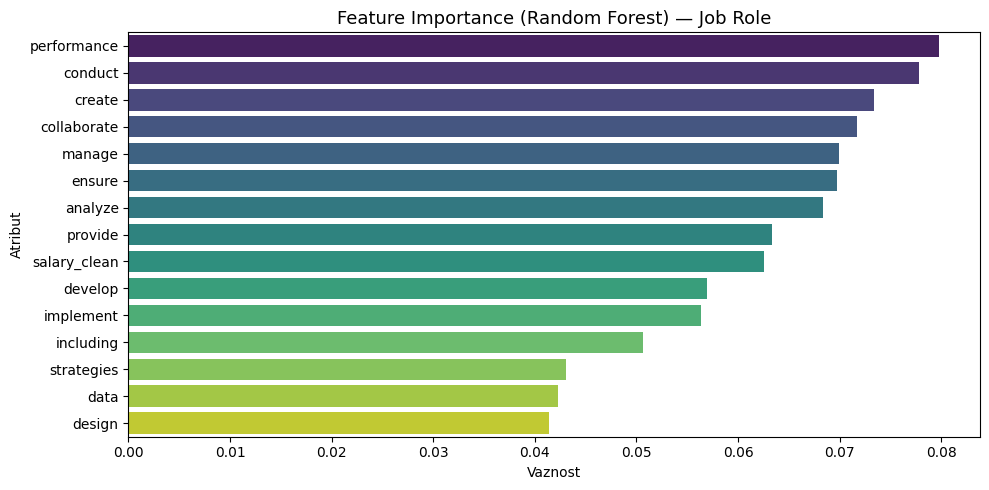


--- Top 15 najvaznijih atributa: Work Type ---


,Feature,Importance
1,salary_clean,0.396681
2,exp_clean,0.286649
3,collaborate,0.030437
4,develop,0.028176
5,design,0.024684
6,provide,0.024077
7,manage,0.023443
8,conduct,0.023175
9,create,0.020970
10,ensure,0.020794


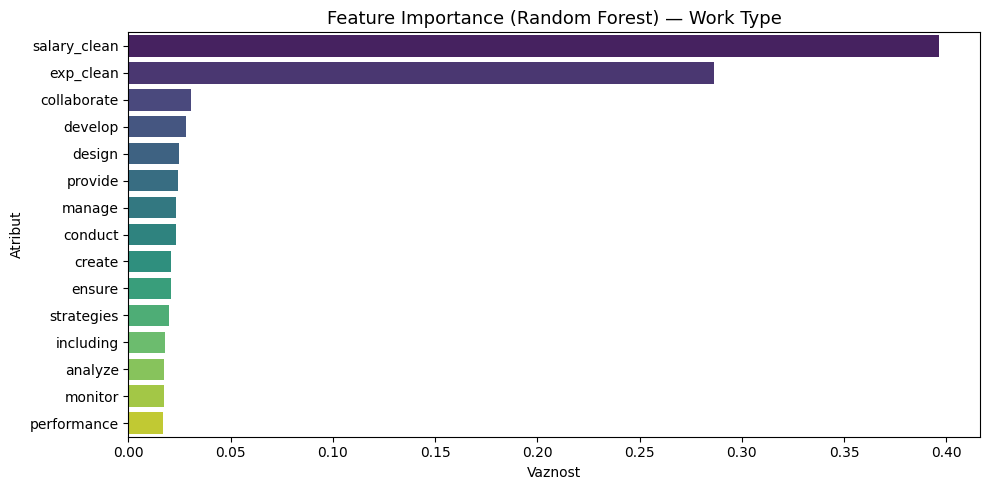


--- Top 15 najvaznijih atributa: Seniority ---


,Feature,Importance
1,salary_clean,0.497278
2,collaborate,0.049615
3,ensure,0.046830
4,develop,0.043689
5,provide,0.039018
6,including,0.038264
7,conduct,0.034626
8,create,0.034374
9,design,0.033795
10,manage,0.030473


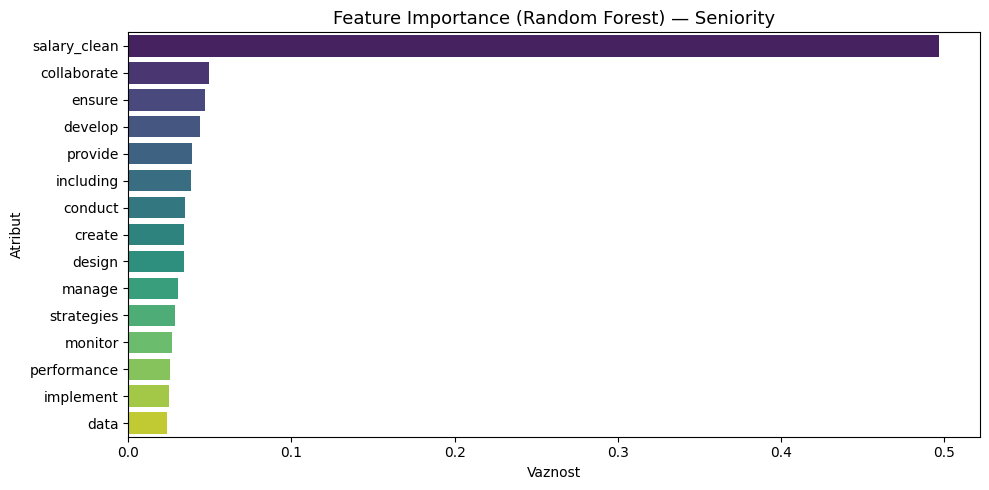


--- Top 15 najvaznijih atributa: Salary Category ---


,Feature,Importance
1,exp_clean,0.445546
2,develop,0.057921
3,design,0.049089
4,collaborate,0.047498
5,including,0.042253
6,create,0.041054
7,analyze,0.038359
8,performance,0.037581
9,conduct,0.036335
10,implement,0.033475


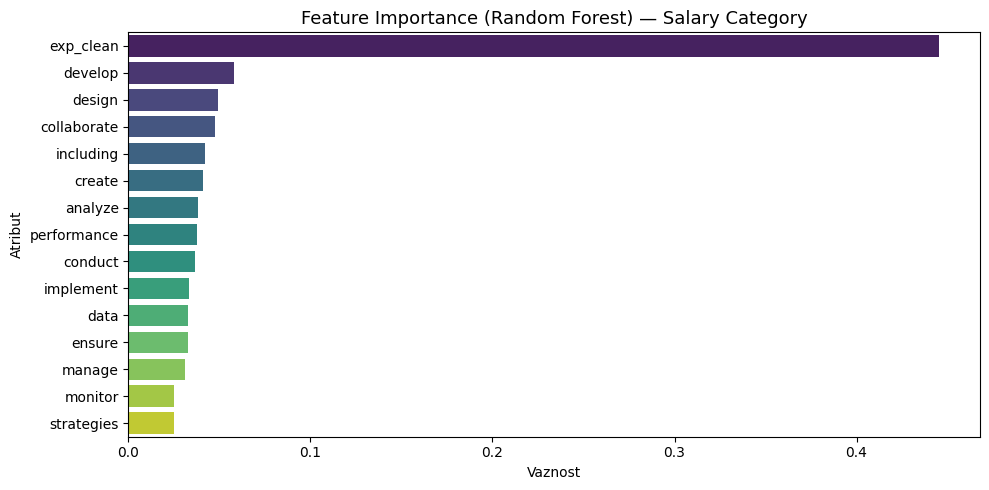

In [ ]:
num_map = {
    'Job Role':        num_features_raw,
    'Work Type':       num_features_raw,
    'Seniority':       num_features_no_exp,
    'Salary Category': num_features_no_sal
}

num_names_map = {
    'Job Role':        ['exp_clean', 'salary_clean'],
    'Work Type':       ['exp_clean', 'salary_clean'],
    'Seniority':       ['salary_clean'],
    'Salary Category': ['exp_clean']
}

tfidf_final = TfidfVectorizer(max_features=15, stop_words='english')
scaler = MinMaxScaler()

for target_name, target_values in targets.items():
    target_key = target_key_map[target_name]

    X_train_text, X_test_text, X_train_num_raw, X_test_num_raw, y_train, y_test = train_test_split(
        df_sample['combined_text'], num_map[target_name], target_values,
        test_size=0.2, random_state=42, stratify=target_values
    )

    X_train_tfidf = tfidf_final.fit_transform(X_train_text).toarray()
    X_train_num   = scaler.fit_transform(X_train_num_raw)
    X_train_fi    = np.hstack((X_train_tfidf, X_train_num))

    feature_names = tfidf_final.get_feature_names_out().tolist() + num_names_map[target_name]

    dt_fi = dt_models[target_name]
    importances = dt_fi.feature_importances_

    fi_df = pd.DataFrame({
        'Feature':    feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15).reset_index(drop=True)
    fi_df.index += 1

    print(f"\n--- Top 15 najvaznijih atributa: {target_name} ---")
    display(fi_df)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
    plt.title(f'Feature Importance (Random Forest) — {target_name}', fontsize=13)
    plt.xlabel('Vaznost')
    plt.ylabel('Atribut')
    plt.tight_layout()
    plt.show()

## Uticaj broja TF-IDF reci na preciznost — Random Forest

In [ ]:
num_map = {
    'Job Role':        num_features_raw,
    'Work Type':       num_features_raw,
    'Seniority':       num_features_no_exp,
    'Salary Category': num_features_no_sal
}

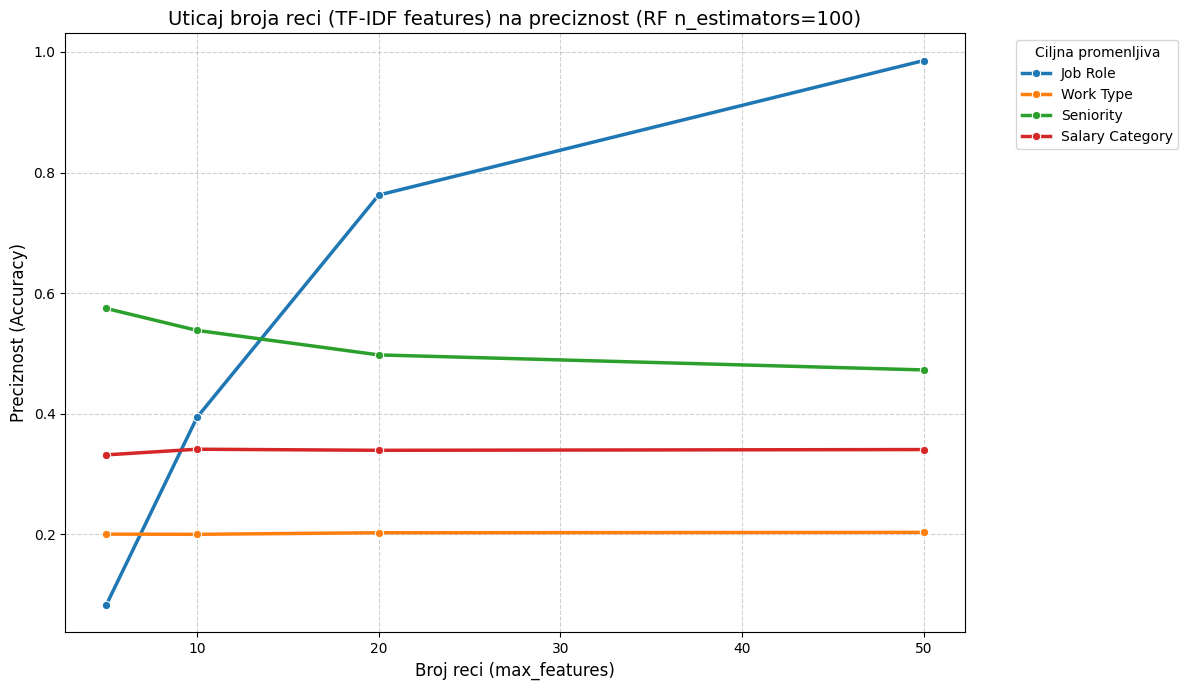

In [ ]:
# lista_reci = [5, 10, 20, 50]
# fiksni_n_estimators = 100
# detaljni_rezultati = []

# for n_features in lista_reci:
#     for naziv, cilj in targets.items():
#         X_train_text, X_test_text, X_train_num_raw, X_test_num_raw, y_train_t, y_test_t = train_test_split(
#             df_sample['combined_text'], num_map[naziv], cilj,
#             test_size=0.2, random_state=42, stratify=cilj
#         )
#         tfidf_iter = TfidfVectorizer(max_features=n_features, stop_words='english')
#         X_train_tfidf = tfidf_iter.fit_transform(X_train_text).toarray()
#         X_test_tfidf  = tfidf_iter.transform(X_test_text).toarray()
#         scaler_iter = MinMaxScaler()
#         X_train_num = scaler_iter.fit_transform(X_train_num_raw)
#         X_test_num  = scaler_iter.transform(X_test_num_raw)
#         X_train_t = np.hstack((X_train_tfidf, X_train_num))
#         X_test_t  = np.hstack((X_test_tfidf, X_test_num))
#         model = RandomForestClassifier(n_estimators=fiksni_n_estimators, random_state=42, n_jobs=-1)
#         model.fit(X_train_t, y_train_t)
#         acc = model.score(X_test_t, y_test_t)
#         detaljni_rezultati.append({"Target": naziv, "Broj_reci": n_features, "Preciznost": acc})

# df_analiza_reci = pd.DataFrame(detaljni_rezultati)
# plt.figure(figsize=(12, 7))
# sns.lineplot(data=df_analiza_reci, x='Broj_reci', y='Preciznost', hue='Target', marker='o', linewidth=2.5)
# plt.title('Uticaj broja reci (TF-IDF features) na preciznost (RF n_estimators=100)', fontsize=14)
# plt.xlabel('Broj reci (max_features)', fontsize=12)
# plt.ylabel('Preciznost (Accuracy)', fontsize=12)
# plt.legend(title='Ciljna promenljiva', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

## Vizualizacija podataka
### 3D PCA vizualizacija

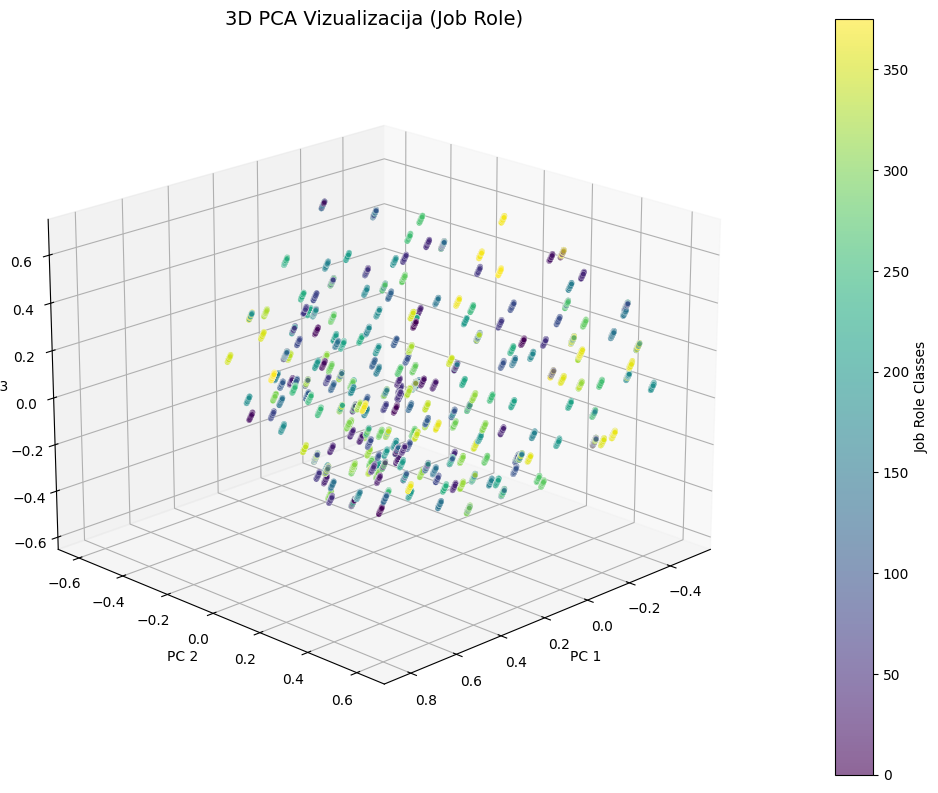

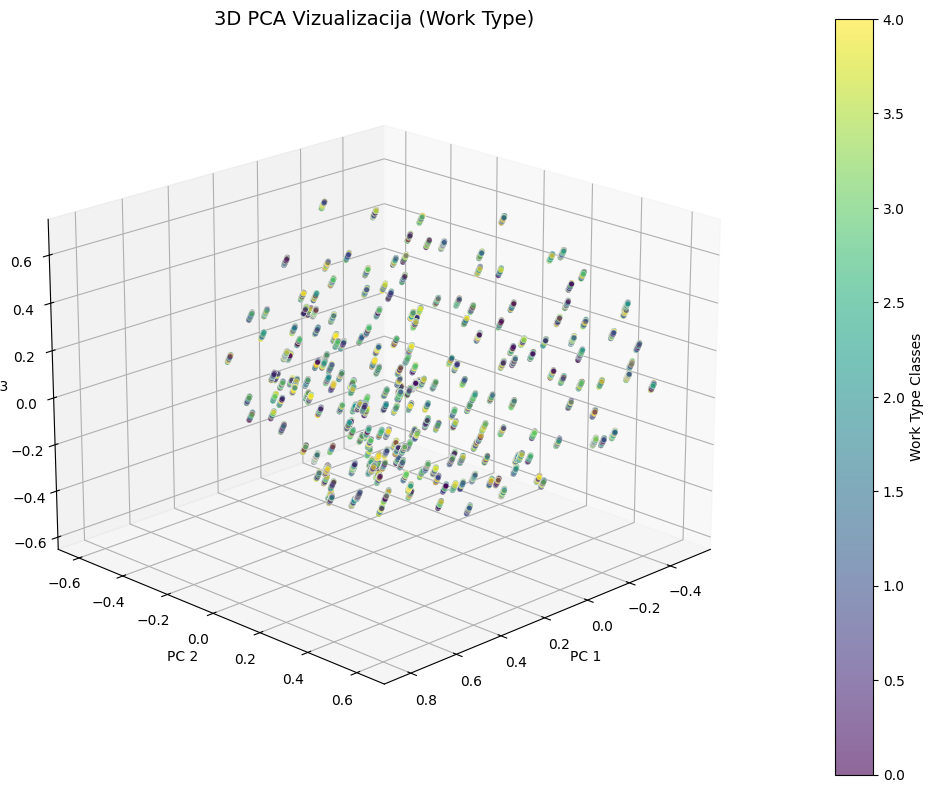

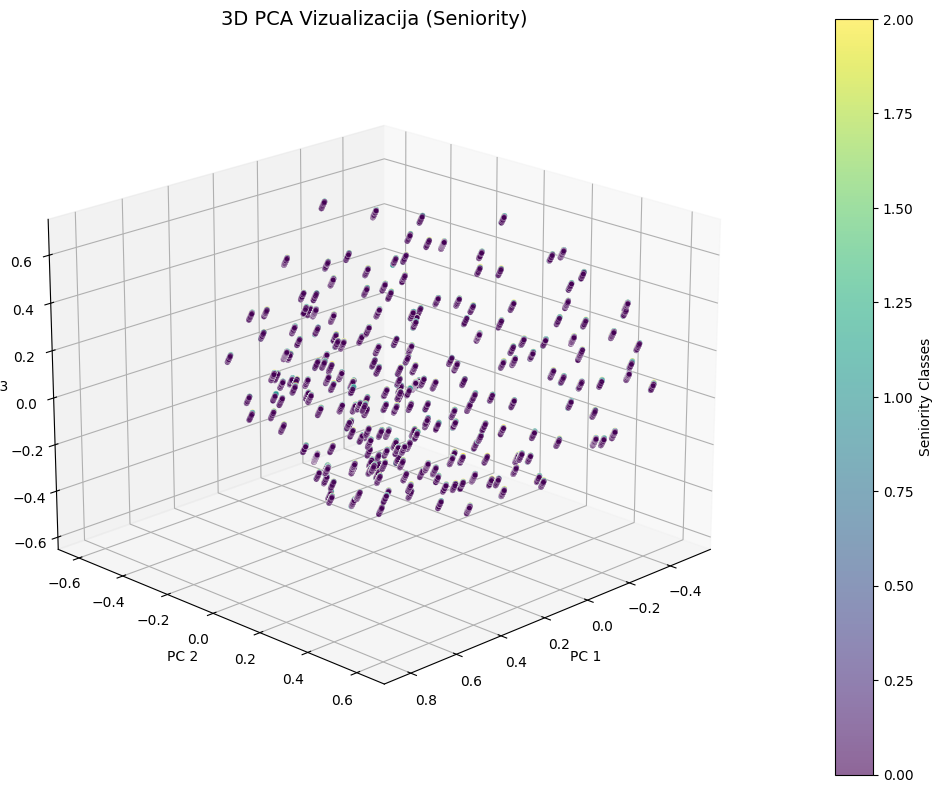

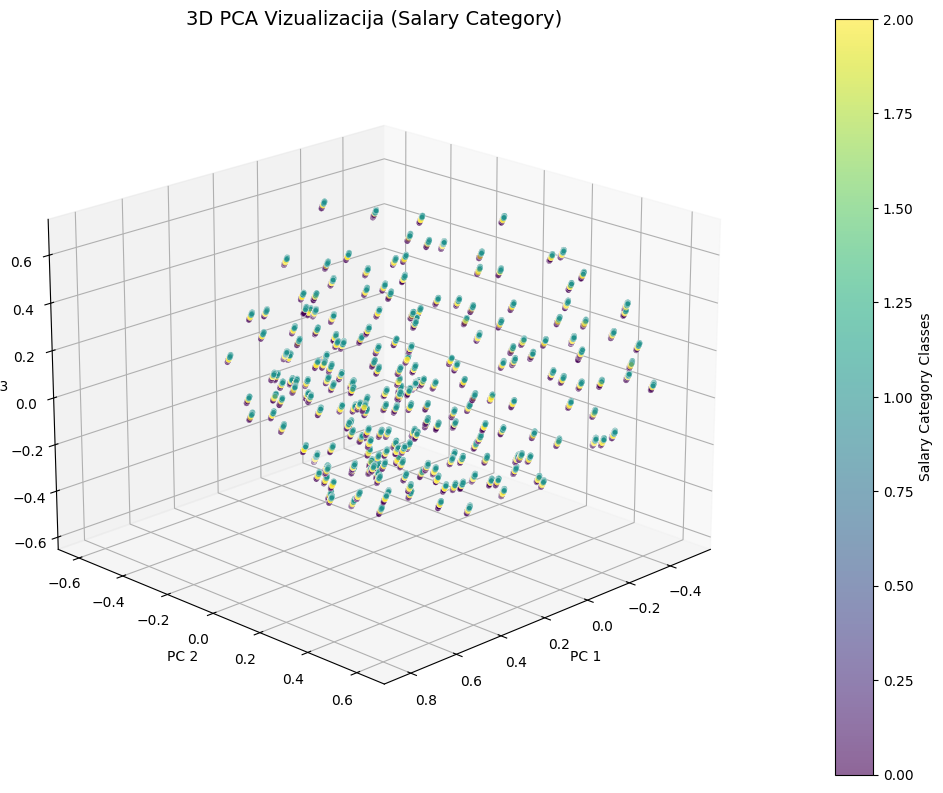

In [ ]:
tfidf_pca = TfidfVectorizer(max_features=15, stop_words='english')
X_text_pca = tfidf_pca.fit_transform(df_sample['combined_text']).toarray()
scaler_pca = MinMaxScaler()
num_pca = scaler_pca.fit_transform(num_features_raw)
X_final_pca = np.hstack((X_text_pca, num_pca))

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_final_pca)

for target_name, target_values in targets.items():
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                         c=target_values, cmap='viridis', alpha=0.6,
                         edgecolors='white', linewidth=0.2, s=15)
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_zlabel('PC 3')
    plt.colorbar(scatter, ax=ax, label=f'{target_name} Classes', pad=0.1)
    plt.title(f'3D PCA Vizualizacija ({target_name})', fontsize=14)
    ax.view_init(elev=20, azim=45)
    plt.tight_layout()
    plt.show()

## Poredenje skupova atributa

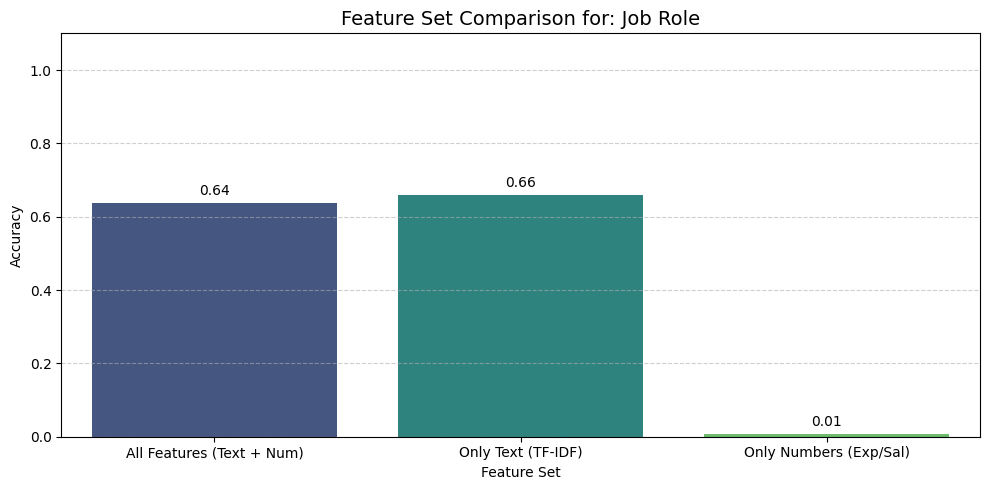

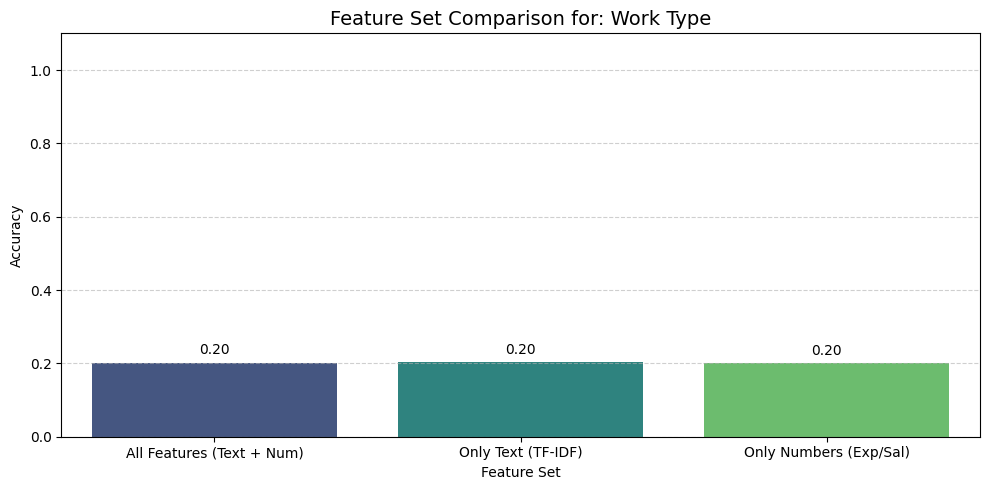

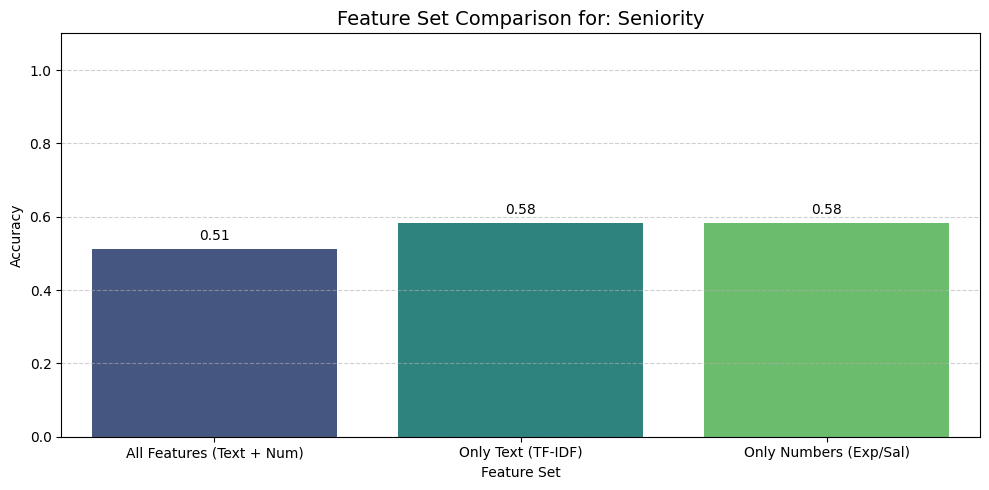

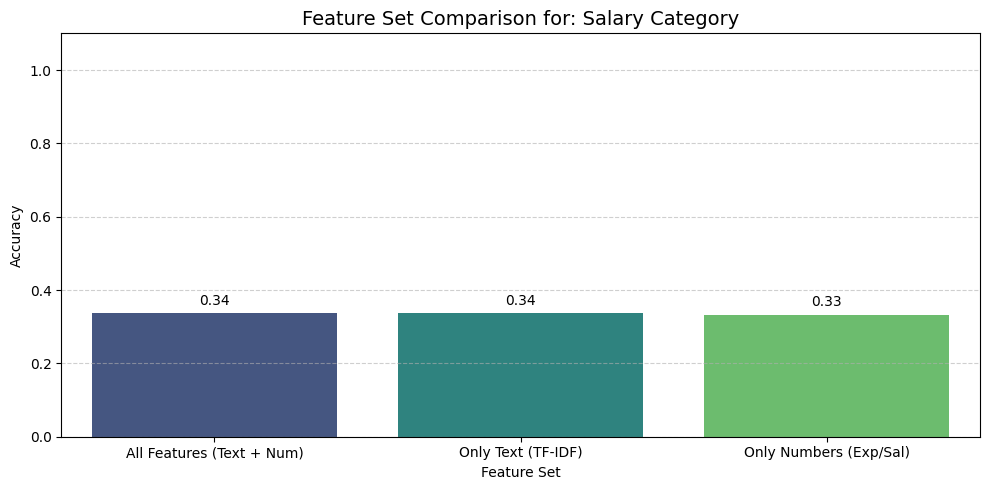

In [ ]:
num_map = {
    'Job Role':        num_features_raw,
    'Work Type':       num_features_raw,
    'Seniority':       num_features_no_exp,
    'Salary Category': num_features_no_sal
}

for target_name, target_values in targets.items():
    comparison_results = []

    X_train_text, X_test_text, X_train_num_raw, X_test_num_raw, y_tr, y_te = train_test_split(
        df_sample['combined_text'], num_map[target_name], target_values,
        test_size=0.2, random_state=42, stratify=target_values
    )

    tfidf_comp = TfidfVectorizer(max_features=15, stop_words='english')
    X_train_tfidf = tfidf_comp.fit_transform(X_train_text).toarray()
    X_test_tfidf  = tfidf_comp.transform(X_test_text).toarray()

    scaler_comp = MinMaxScaler()
    X_train_num = scaler_comp.fit_transform(X_train_num_raw)
    X_test_num  = scaler_comp.transform(X_test_num_raw)

    feature_sets = {
        "All Features (Text + Num)": (np.hstack((X_train_tfidf, X_train_num)),
                                      np.hstack((X_test_tfidf, X_test_num))),
        "Only Text (TF-IDF)":        (X_train_tfidf, X_test_tfidf),
        "Only Numbers (Exp/Sal)":    (X_train_num, X_test_num)
    }

    for set_name, (X_tr, X_te) in feature_sets.items():
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_tr, y_tr)
        acc = model.score(X_te, y_te)
        comparison_results.append({"Feature Set": set_name, "Accuracy": acc})

    df_comp = pd.DataFrame(comparison_results)
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x='Feature Set', y='Accuracy', data=df_comp, palette='viridis')
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points')
    plt.title(f'Feature Set Comparison for: {target_name}', fontsize=14)
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
import os

fajlovi = os.listdir('/content/drive/MyDrive/modeli_V2')
for f in sorted(fajlovi):
    print(f)

label_encoder_role.pkl
label_encoder_salary.pkl
label_encoder_seniority.pkl
label_encoder_work_type.pkl
model_decision_tree_role.pkl
model_decision_tree_salary_category.pkl
model_decision_tree_seniority.pkl
model_decision_tree_work_type.pkl
model_knn_role.pkl
model_knn_salary_category.pkl
model_knn_seniority.pkl
model_knn_work_type.pkl
model_logistic_regression_role.pkl
model_logistic_regression_salary_category.pkl
model_logistic_regression_seniority.pkl
model_logistic_regression_work_type.pkl
model_naive_bayes_role.pkl
model_naive_bayes_salary_category.pkl
model_naive_bayes_seniority.pkl
model_naive_bayes_work_type.pkl
model_random_forest_salary_category.pkl
model_random_forest_seniority.pkl
model_random_forest_work_type.pkl
scaler_role.pkl
scaler_salary_category.pkl
scaler_seniority.pkl
scaler_work_type.pkl
tfidf_role.pkl
tfidf_salary_category.pkl
tfidf_seniority.pkl
tfidf_work_type.pkl


In [ ]:
import joblib

najbolji_role = joblib.load('/content/drive/MyDrive/modeli_V2/model_decision_tree_role.pkl')

najbolji_seniority = joblib.load('/content/drive/MyDrive/modeli_V2/model_random_forest_seniority.pkl')

najbolji_salary = joblib.load('/content/drive/MyDrive/modeli_V2/model_decision_tree_salary_category.pkl')

najbolji_work_type = joblib.load('/content/drive/MyDrive/modeli_V2/model_logistic_regression_work_type.pkl')

In [ ]:
classifiers_best_ucitani = {
    "Job Role": najbolji_role,
    "Seniority": najbolji_seniority,
    "Salary Category": najbolji_salary,
    "Work Type": najbolji_work_type
}

## Cross-Validation

In [ ]:
from sklearn.pipeline import Pipeline

tfidf_cv = TfidfVectorizer(max_features=15, stop_words='english')
X_text_cv = tfidf_cv.fit_transform(df_sample['combined_text']).toarray()

cv_results = []

for target_name, target_values in targets.items():
  model = classifiers_best_ucitani[target_name]

  num_cv = MinMaxScaler().fit_transform(num_map[target_name])
  X_cv = np.hstack((X_text_cv, num_cv))

  pipe = Pipeline([
  ('scaler', MinMaxScaler()),
  ('classifier', model)
  ])

  print(f"Validacija  {target_name} koristeći {type(model).__name__}...")

  scores = cross_val_score(pipe, X_cv, target_values, cv=5, scoring='accuracy', n_jobs=-1)

  cv_results.append({
  'Target':    target_name,
  'Algorithm': type(model).__name__,
  'CV Mean':   scores.mean(),
  'CV Std':    scores.std()
  })
  print(f"Zavrseno: {scores.mean():.4f} +/- {scores.std():.4f}")

Validacija  Job Role koristeći DecisionTreeClassifier...
Zavrseno: 0.6418 +/- 0.0008
Validacija  Work Type koristeći LogisticRegression...
Zavrseno: 0.1964 +/- 0.0025
Validacija  Seniority koristeći RandomForestClassifier...
Zavrseno: 0.5506 +/- 0.0039
Validacija  Salary Category koristeći DecisionTreeClassifier...
Zavrseno: 0.3276 +/- 0.0046


In [ ]:
df_final_cv = pd.DataFrame(cv_results)
display(df_final_cv)

,Target,Algorithm,CV Mean,CV Std
0,Job Role,DecisionTreeClassifier,0.641795,0.000821
1,Work Type,LogisticRegression,0.196446,0.002452
2,Seniority,RandomForestClassifier,0.550577,0.003904
3,Salary Category,DecisionTreeClassifier,0.327616,0.004648


### Vizualizacija CV rezultata po targetima

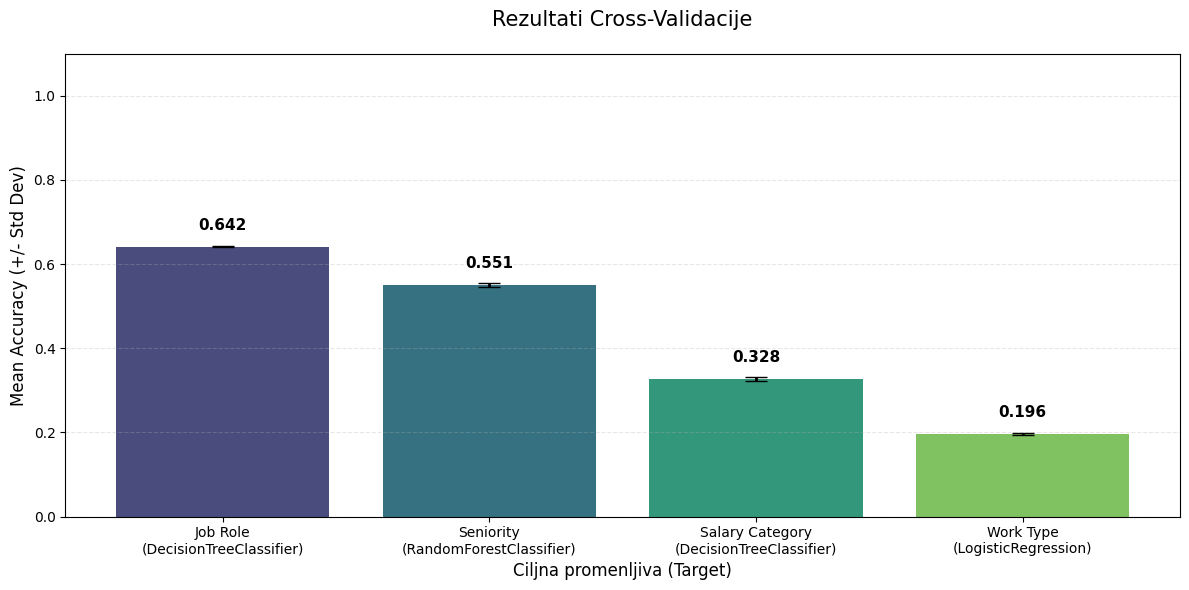

In [ ]:
df_cv_sorted = df_final_cv.sort_values('CV Mean', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Target', y='CV Mean', data=df_cv_sorted, palette='viridis')

plt.errorbar(x=range(len(df_cv_sorted)), y=df_cv_sorted['CV Mean'],
             yerr=df_cv_sorted['CV Std'], fmt='none', color='black', capsize=8, elinewidth=2)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 10), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Rezultati Cross-Validacije', fontsize=15, pad=20)
plt.ylabel('Mean Accuracy (+/- Std Dev)', fontsize=12)
plt.xlabel('Ciljna promenljiva (Target)', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

new_labels = [f"{row['Target']}\n({row['Algorithm']})" for _, row in df_cv_sorted.iterrows()]
ax.set_xticklabels(new_labels)

plt.tight_layout()
plt.show()